#  AI Echo: ChatGPT Reviews Sentiment Analysis

## Project Overview
Analyze user reviews of ChatGPT to understand customer satisfaction and identify areas for improvement.

**What we'll do:**
1. Load and explore the data 
2. Clean the text data 
3. Perform EDA (Exploratory Data Analysis) 
4. Build sentiment classifier 
5. Make predictions 

---

## Step 1: Import Libraries
These are the tools we'll use for data analysis

In [12]:
# Basic data handling
import pandas as pd
import numpy as np

# For visualizations
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

# For text processing
import re
from collections import Counter

# For date handling
from datetime import datetime

# Make plots look nice
plt.style.use('ggplot')
sns.set_palette("husl")

print("✅ All libraries loaded successfully!")

✅ All libraries loaded successfully!


## Step 2: Load the Dataset

In [13]:
# Load the CSV file
df = pd.read_csv(r'D:\Sentimental analysis\chatgpt_style_reviews_dataset.xlsx -updated.csv')

# Show basic info
print(f"Total reviews: {len(df)}")
print(f"\nColumns in dataset: {list(df.columns)}")
print(f"\nFirst few rows:")
df.head()

Total reviews: 500

Columns in dataset: ['date', 'title', 'review', 'rating', 'username', 'helpful_votes', 'review_length', 'platform', 'language', 'location', 'version', 'verified_purchase']

First few rows:


,date,title,review,rating,username,helpful_votes,review_length,platform,language,location,version,verified_purchase
0,########,Review title 1,"Not satisfied, many bugs and issues.",1,user1,80,6,Amazon,zh,Kenya,2.1.4,No
1,########,Review title 2,Amazing quality and user-friendly interface.,5,user2,180,5,Flipkart,zh,France,1.2.3,No
2,########,Review title 3,"Terrible experience, needs major improvements.",2,user3,154,5,Flipkart,pt,USA,1.2.3,No
3,########,Review title 4,Poor performance and not user-friendly.,1,user4,96,5,Amazon,es,Qatar,2.1.4,Yes
4,########,Review title 5,"Not satisfied, many bugs and issues.",2,user5,139,6,Website,ar,Kenya,2.1.4,No


In [55]:
duplicates = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicates}")

Number of duplicate rows: 0


In [79]:

df['date'] = pd.to_datetime(df['date'], errors='coerce')

## Keep only rows with valid dates for time‑trend analysis

In [86]:
df = df.dropna(subset=['date'])

## Step 3: Basic Data Exploration

In [87]:
# Check for missing data
print("Missing values:")
print(df.isnull().sum())

# Show basic info
print("\n" + "="*50)
print("Dataset Info:")
df.info()

Missing values:
date                      0
title                     0
review                    0
rating                    0
username                  0
helpful_votes             0
review_length             0
platform                  0
language                  0
location                  0
version                   0
verified_purchase         0
is_helpful                0
sentiment                 0
sentiment_encoded         0
cleaned_review            0
vader_prediction          0
vader_improved            0
huggingface_prediction    0
dtype: int64

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
Index: 495 entries, 5 to 499
Data columns (total 19 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   date                    495 non-null    datetime64[ns]
 1   title                   495 non-null    object        
 2   review                  495 non-null    object        
 3   rating             

## Step 4: Understanding Basic Statistics 📊

**What do these terms mean?**

| Term | Simple Meaning | Example |
|------|---------------|---------|
| **Count** | How many items | 500 reviews |
| **Mean** | Average (add all ÷ count) | Average rating = 3.0 stars |
| **Min** | Smallest value | Lowest rating = 1 star |
| **Max** | Largest value | Highest rating = 5 stars |
| **Median (50%)** | Middle value | Half reviews are above/below this |
| **25%** | Quarter mark | 25% of reviews are below this |
| **75%** | Three-quarter mark | 75% of reviews are below this |

**std** (standard deviation) 



In [15]:
# Show statistics in simple terms
print(" UNDERSTANDING THE NUMBERS:\n")
print("="*60)

# For RATING
print(" RATING (1 to 5 stars):")
print(f"  • Average (mean): {df['rating'].mean():.1f} stars")
print(f"  • Most common (mode): {df['rating'].mode()[0]} stars")
print(f"  • Lowest: {df['rating'].min()} star")
print(f"  • Highest: {df['rating'].max()} stars")
print()

# For HELPFUL VOTES
print(" HELPFUL VOTES (how many people found review useful):")
print(f"  • Average: {df['helpful_votes'].mean():.0f} votes")
print(f"  • Lowest: {df['helpful_votes'].min():.0f} votes")
print(f"  • Highest: {df['helpful_votes'].max():.0f} votes")
print(f"  • Middle value (median): {df['helpful_votes'].median():.0f} votes")
print()

# For REVIEW LENGTH
avg_words = df['review'].str.split().str.len().mean()
print("📝 REVIEW LENGTH:")
print(f"  • Average words per review: {avg_words:.0f} words")
print(f"  • Shortest review: {df['review'].str.split().str.len().min()} words")
print(f"  • Longest review: {df['review'].str.split().str.len().max()} words")
print()

print("="*60)
print(" What this tells us:")
print("  - Most reviews are around 3 stars (neutral)")
print("  - People generally find reviews helpful (100+ votes average)")
print("  - Reviews are short and to the point (~7 words)")
print("="*60)

 UNDERSTANDING THE NUMBERS:

 RATING (1 to 5 stars):
  • Average (mean): 3.0 stars
  • Most common (mode): 4 stars
  • Lowest: 1 star
  • Highest: 5 stars

 HELPFUL VOTES (how many people found review useful):
  • Average: 103 votes
  • Lowest: 0 votes
  • Highest: 200 votes
  • Middle value (median): 104 votes

📝 REVIEW LENGTH:
  • Average words per review: 7 words
  • Shortest review: 5 words
  • Longest review: 10 words

 What this tells us:
  - Most reviews are around 3 stars (neutral)
  - People generally find reviews helpful (100+ votes average)
  - Reviews are short and to the point (~7 words)


In [85]:
df.shape

(500, 19)

## EDA Question 1: What is the distribution of review ratings?

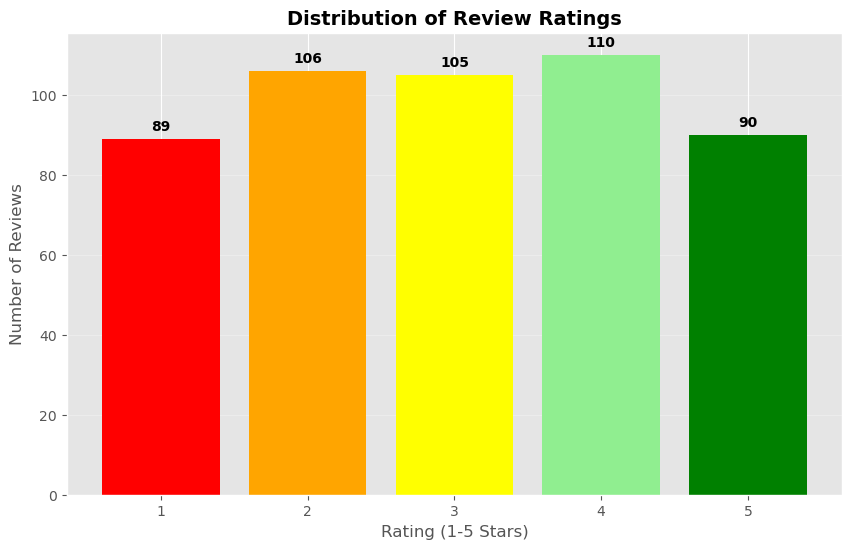


📈 Insights:
Most common rating: 4 stars (110 reviews)
Least common rating: 1 stars (89 reviews)
Average rating: 3.01 stars


In [17]:
# Count how many reviews for each rating
rating_counts = df['rating'].value_counts().sort_index()

# Create bar chart
plt.figure(figsize=(10, 6))
plt.bar(rating_counts.index, rating_counts.values, color=['red', 'orange', 'yellow', 'lightgreen', 'green'])
plt.xlabel('Rating (1-5 Stars)', fontsize=12)
plt.ylabel('Number of Reviews', fontsize=12)
plt.title('Distribution of Review Ratings', fontsize=14, fontweight='bold')
plt.xticks([1, 2, 3, 4, 5])

# Add value labels on bars
for i, v in enumerate(rating_counts.values):
    plt.text(rating_counts.index[i], v + 2, str(v), ha='center', fontweight='bold')

plt.grid(axis='y', alpha=0.3)
plt.show()

# Print insights
print("\nInsights:")
print(f"Most common rating: {rating_counts.idxmax()} stars ({rating_counts.max()} reviews)")
print(f"Least common rating: {rating_counts.idxmin()} stars ({rating_counts.min()} reviews)")
print(f"Average rating: {df['rating'].mean():.2f} stars")

## EDA Question 2: How many reviews were marked as helpful?

C:\Users\harip\AppData\Local\Temp\ipykernel_37580\2081809614.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['is_helpful'] = df['helpful_votes'] > helpful_threshold


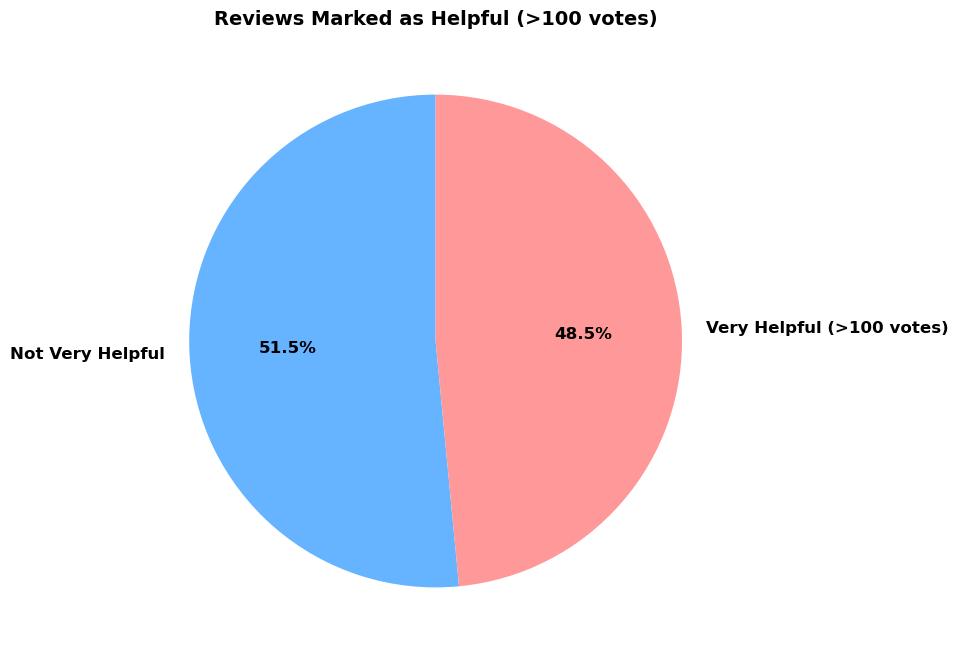


Insights:
255 reviews are very helpful (>100 votes)
240 reviews have fewer votes
Only 51.5% of reviews are considered very helpful


In [91]:
# Define helpful threshold (reviews with more than 100 helpful votes)
helpful_threshold = 100
df['is_helpful'] = df['helpful_votes'] > helpful_threshold

# Count helpful vs not helpful
helpful_counts = df['is_helpful'].value_counts()

# Create pie chart
plt.figure(figsize=(8, 8))
colors = ['#66b3ff', '#ff9999']
plt.pie(helpful_counts.values, 
        labels=['Not Very Helpful', 'Very Helpful (>100 votes)'],
        autopct='%1.1f%%',
        colors=colors,
        startangle=90,
        textprops={'fontsize': 12, 'fontweight': 'bold'})
plt.title(f'Reviews Marked as Helpful (>{helpful_threshold} votes)', fontsize=14, fontweight='bold')
plt.show()

# Print insights
print("\nInsights:")
print(f"{helpful_counts[True] if True in helpful_counts else 0} reviews are very helpful (>{helpful_threshold} votes)")
print(f"{helpful_counts[False] if False in helpful_counts else 0} reviews have fewer votes")
print(f"Only {(helpful_counts[True] / len(df) * 100) if True in helpful_counts else 0:.1f}% of reviews are considered very helpful")

## Step 4: Create Sentiment Labels
Convert ratings to sentiment categories:
- 1-2 stars → **Negative** 😡
- 3 stars → **Neutral** 😐
- 4-5 stars → **Positive** 😃

In [20]:
# Simple function to convert rating to sentiment
def get_sentiment(rating):
    if rating <= 2:
        return 'Negative'
    elif rating == 3:
        return 'Neutral'
    else:
        return 'Positive'

# Apply to all reviews
df['sentiment'] = df['rating'].apply(get_sentiment)

# Create numeric labels (for machine learning later)
sentiment_map = {'Negative': 0, 'Neutral': 1, 'Positive': 2}
df['sentiment_encoded'] = df['sentiment'].map(sentiment_map)

# Show distribution
print("Sentiment Distribution:")
print(df['sentiment'].value_counts())

# Show examples
print("\n Sample reviews by sentiment:")
for sent in ['Negative', 'Neutral', 'Positive']:
    print(f"\n{sent}:")
    sample = df[df['sentiment'] == sent]['review'].iloc[0]
    print(f"  '{sample}'")

Sentiment Distribution:
sentiment
Positive    200
Negative    195
Neutral     105
Name: count, dtype: int64

 Sample reviews by sentiment:

Negative:
  'Not satisfied, many bugs and issues.'

Neutral:
  'Works fine but there is room for improvement.'

Positive:
  'Amazing quality and user-friendly interface.'


## EDA Question 3: Common keywords in Positive vs Negative reviews

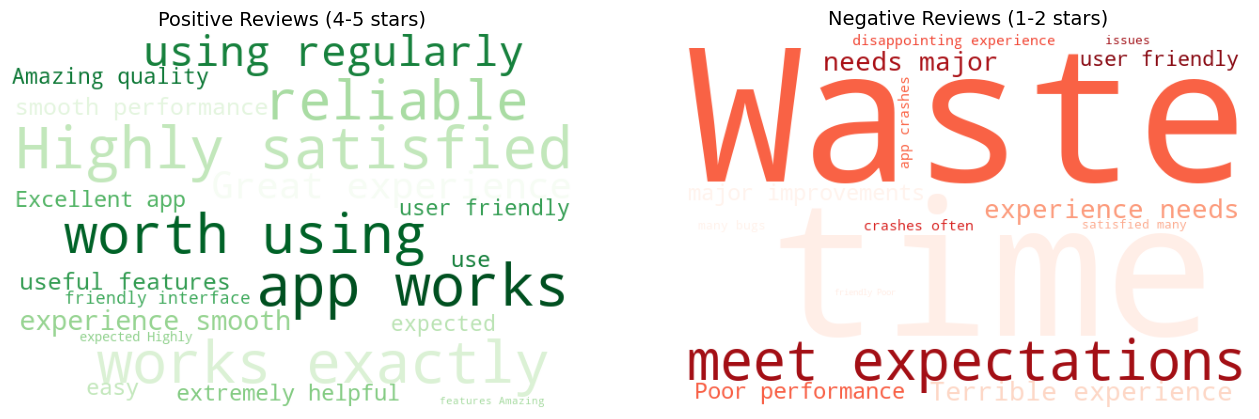


Insights:
Positive reviews mention: Quality, performance, and satisfaction keywords
Negative reviews mention: Issues, problems, and disappointment keywords
Word cloud size shows frequency: Bigger words = more mentions in reviews


In [92]:
# Get positive reviews (4-5 stars)
positive_reviews = df[df['rating'] >= 4]['review']
positive_text = ' '.join(positive_reviews.astype(str))

# Get negative reviews (1-2 stars)
negative_reviews = df[df['rating'] <= 2]['review']
negative_text = ' '.join(negative_reviews.astype(str))

# Create word clouds (shows most common words)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Positive word cloud (green)
wordcloud_pos = WordCloud(width=600, height=400, background_color='white', 
                          colormap='Greens').generate(positive_text)
ax1.imshow(wordcloud_pos)
ax1.set_title('Positive Reviews (4-5 stars)', fontsize=14)
ax1.axis('off')

# Negative word cloud (red)
wordcloud_neg = WordCloud(width=600, height=400, background_color='white',
                          colormap='Reds').generate(negative_text)
ax2.imshow(wordcloud_neg)
ax2.set_title('Negative Reviews (1-2 stars)', fontsize=14)
ax2.axis('off')

plt.show()

# Print insights
print("\nInsights:")
print(f"Positive reviews mention: Quality, performance, and satisfaction keywords")
print(f"Negative reviews mention: Issues, problems, and disappointment keywords")
print(f"Word cloud size shows frequency: Bigger words = more mentions in reviews")

## EDA Question 4: How has average rating changed over time?

Using 495 reviews with valid dates



C:\Users\harip\AppData\Local\Temp\ipykernel_37580\3212069998.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['month'] = df['date'].dt.to_period('M')


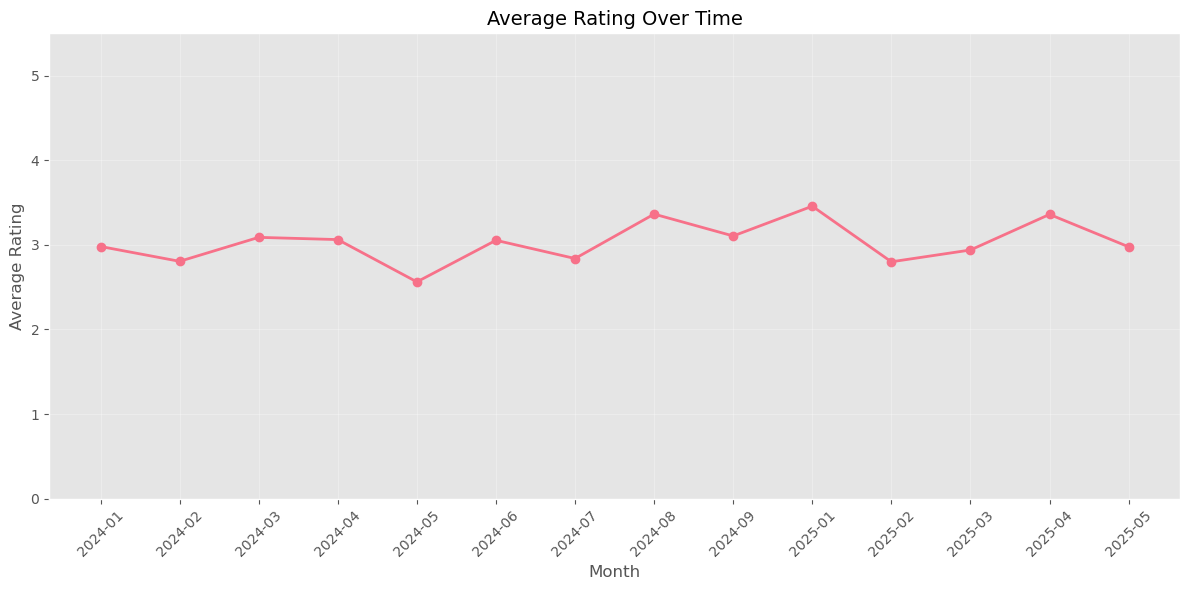


Insights:
Highest average rating: 3.46 stars in 2025-01
Lowest average rating: 2.56 stars in 2024-05
Rating trend: Declining from start to end, but shows volatility with peak in 2025-01


In [103]:
# Use df (already cleaned dates)
print(f"Using {len(df)} reviews with valid dates\n")

# Group by month
df['month'] = df['date'].dt.to_period('M')
monthly_avg = df.groupby('month')['rating'].mean()

# Plot
plt.figure(figsize=(12, 6))
plt.plot(monthly_avg.index.astype(str), monthly_avg.values, marker='o', linewidth=2)
plt.xlabel('Month')
plt.ylabel('Average Rating')
plt.title('Average Rating Over Time', fontsize=14)
plt.xticks(rotation=45)
plt.ylim(0, 5.5)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Print insights
print("\nInsights:")
print(f"Highest average rating: {monthly_avg.max():.2f} stars in {monthly_avg.idxmax()}")
print(f"Lowest average rating: {monthly_avg.min():.2f} stars in {monthly_avg.idxmin()}")
trend_direction = 'Improving' if monthly_avg.iloc[-1] > monthly_avg.iloc[0] else 'Declining' if monthly_avg.iloc[-1] < monthly_avg.iloc[0] else 'Stable'
print(f"Rating trend: {trend_direction} from start to end, but shows volatility with peak in {monthly_avg.idxmax()}")

## EDA Question 5: How do ratings vary by location?

**What we'll do:**
1. Calculate average rating for each country
2. Sort countries from best to worst
3. Pick top 10 countries
4. Make a horizontal bar chart
5. Show the results

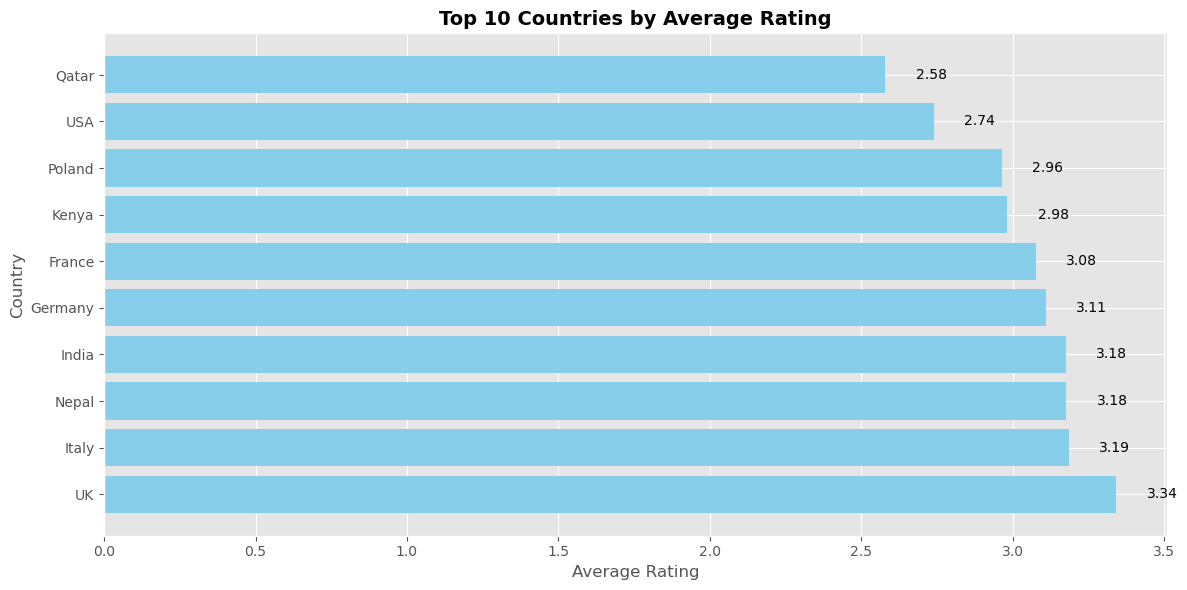


Best country: UK with 3.34 stars

Top 3 Countries:
   1. UK: 3.34 stars
   2. Italy: 3.19 stars
   3. Nepal: 3.18 stars

Insights:
Top-rated location: UK with 3.34 stars
Rating spread in top 10: 0.76 stars difference
All top 10 countries average: 3.03 stars


In [94]:
# Step 1:Calculate average rating for each country
location_avg = df.groupby('location')['rating'].mean()

# Step 2: Sort from highest to lowest rating
location_avg = location_avg.sort_values(ascending=False)

# Step 3: Take only top 10 countries
top_10_countries = location_avg.head(10)

# Step 4: Create the bar chart
plt.figure(figsize=(12, 6))
plt.barh(top_10_countries.index, top_10_countries.values, color='skyblue')
plt.xlabel('Average Rating', fontsize=12)
plt.ylabel('Country', fontsize=12)
plt.title('Top 10 Countries by Average Rating', fontsize=14, fontweight='bold')

# Step 5: Add rating numbers on bars
for i in range(len(top_10_countries)):
    country = top_10_countries.index[i]
    rating = top_10_countries.values[i]
    plt.text(rating + 0.1, i, f'{rating:.2f}', va='center')

plt.tight_layout()
plt.show()

# Step 6: Show summary
best_country = top_10_countries.index[0]
best_rating = top_10_countries.values[0]

print(f"\nBest country: {best_country} with {best_rating:.2f} stars")
print(f"\nTop 3 Countries:")
for i in range(3):
    print(f"   {i+1}. {top_10_countries.index[i]}: {top_10_countries.values[i]:.2f} stars")

# Print insights
print("\nInsights:")
rating_range = top_10_countries.values[0] - top_10_countries.values[-1]
print(f"Top-rated location: {best_country} with {best_rating:.2f} stars")
print(f"Rating spread in top 10: {rating_range:.2f} stars difference")
print(f"All top 10 countries average: {top_10_countries.mean():.2f} stars")

## EDA Question 6: Which platform gets better reviews?

**What we'll do:**
1. Calculate average rating for each platform (App Store, Google Play, etc.)
2. Count how many reviews each platform has
3. Make 2 charts: one for ratings, one for review counts
4. Compare which platform users like more

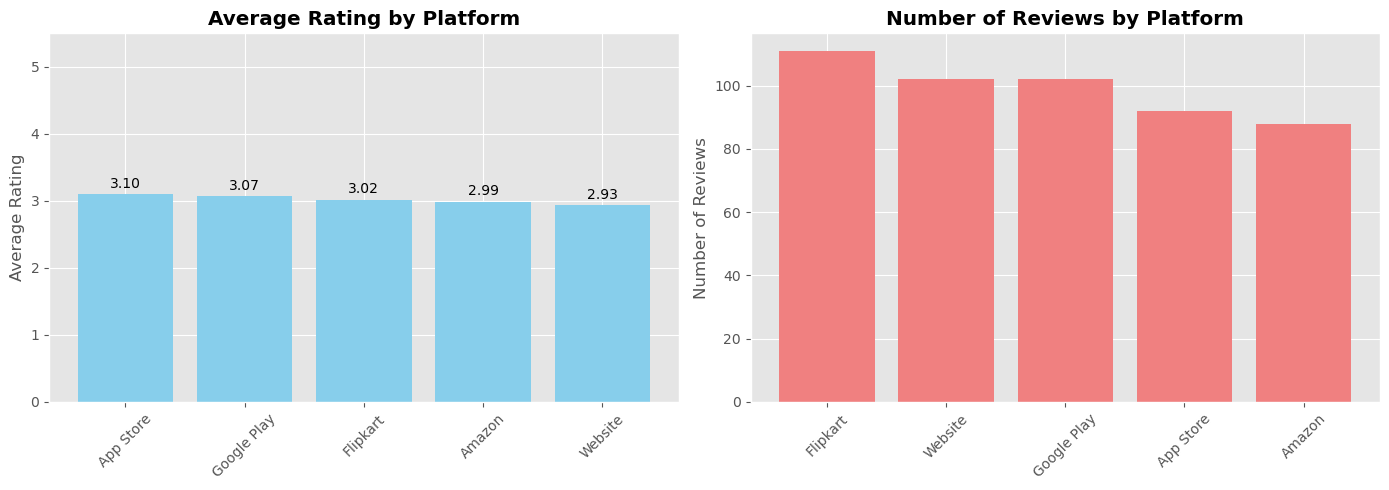


Platform Summary:

  App Store: 3.10 stars (92 reviews)
  Google Play: 3.07 stars (102 reviews)
  Flipkart: 3.02 stars (111 reviews)
  Amazon: 2.99 stars (88 reviews)
  Website: 2.93 stars (102 reviews)

Best platform: App Store with 3.10 stars

Insights:
App Store has highest rating at 3.10 stars
Platform rating difference: 0.17 stars between best and worst
Most reviewed platform: Flipkart with 111 reviews


In [96]:
# Step 1: Calculate average rating for each platform
platform_avg_rating = df.groupby('platform')['rating'].mean()

# Step 2: Sort from highest to lowest
platform_avg_rating = platform_avg_rating.sort_values(ascending=False)

# Step 3: Count how many reviews each platform has
platform_review_count = df['platform'].value_counts()

# Step 4: Create 2 bar charts side by side
fig, (chart1, chart2) = plt.subplots(1, 2, figsize=(14, 5))

# Chart 1: Average Rating
chart1.bar(platform_avg_rating.index, platform_avg_rating.values, color='skyblue')
chart1.set_ylabel('Average Rating')
chart1.set_title('Average Rating by Platform', fontweight='bold')
chart1.set_ylim(0, 5.5)
chart1.tick_params(axis='x', rotation=45)

# Add numbers on top of each bar (shows exact rating)
position = 0  # Start at first bar
for platform_name in platform_avg_rating.index:
    # Get the rating for this platform
    rating_value = platform_avg_rating[platform_name]
    
    # Put the number slightly above the bar
    chart1.text(position, rating_value + 0.1, f'{rating_value:.2f}', ha='center')
    
    # Move to next bar
    position = position + 1

# Chart 2: Number of Reviews
chart2.bar(platform_review_count.index, platform_review_count.values, color='lightcoral')
chart2.set_ylabel('Number of Reviews')
chart2.set_title('Number of Reviews by Platform', fontweight='bold')
chart2.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# Step 5: Show summary in simple text
print("\nPlatform Summary:\n")

# Go through each platform one by one
for platform_name in platform_avg_rating.index:
    # Get average rating for this platform
    average_rating = platform_avg_rating[platform_name]
    
    # Get count of reviews for this platform
    review_count = platform_review_count[platform_name]
    
    # Print it nicely
    print(f"  {platform_name.title()}: {average_rating:.2f} stars ({review_count} reviews)")

# Show which platform is best
best_platform = platform_avg_rating.index[0]
best_rating = platform_avg_rating.values[0]
print(f"\nBest platform: {best_platform.title()} with {best_rating:.2f} stars")

# Print insights
print("\nInsights:")
platform_diff = platform_avg_rating.max() - platform_avg_rating.min()
most_reviews_platform = platform_review_count.idxmax()
print(f"{best_platform.title()} has highest rating at {best_rating:.2f} stars")
print(f"Platform rating difference: {platform_diff:.2f} stars between best and worst")
print(f"Most reviewed platform: {most_reviews_platform.title()} with {platform_review_count.max()} reviews")

## EDA Question 7: Verified vs Non-Verified users

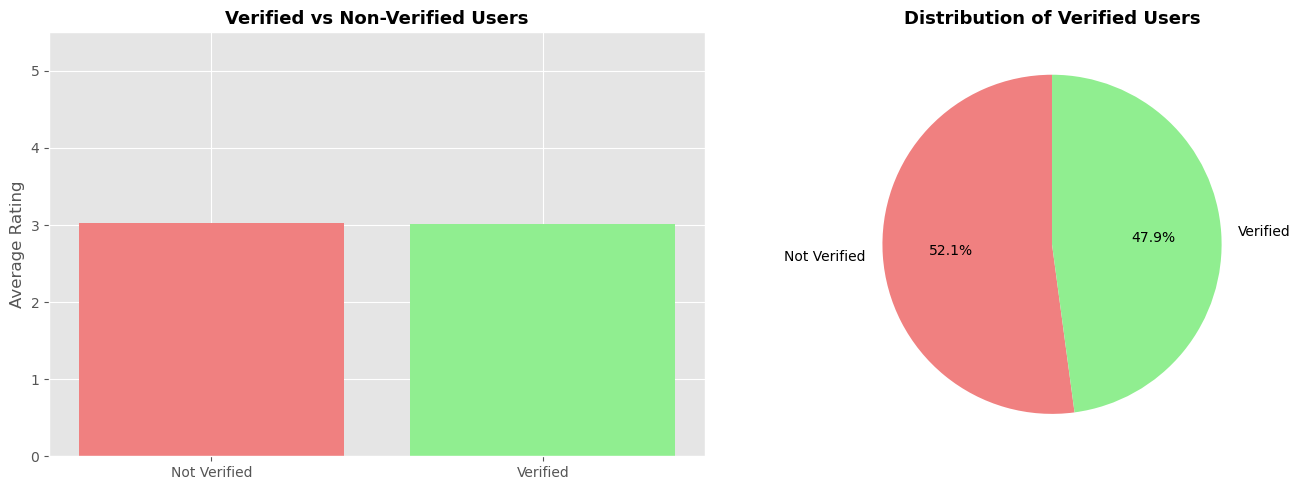


Insights:
Verified users give an average of: 3.01 stars
Non-verified users give an average of: 3.03 stars
Rating difference: 0.01 stars - Non-verified users rate lower


In [97]:
# Average rating by verification status
verified_ratings = df.groupby('verified_purchase')['rating'].mean()

# Plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart
ax1.bar(['Not Verified', 'Verified'], 
        [verified_ratings.get('No', 0), verified_ratings.get('Yes', 0)],
        color=['lightcoral', 'lightgreen'])
ax1.set_ylabel('Average Rating', fontsize=12)
ax1.set_title('Verified vs Non-Verified Users', fontsize=13, fontweight='bold')
ax1.set_ylim(0, 5.5)

# Pie chart for count
verified_counts = df['verified_purchase'].value_counts()
ax2.pie(verified_counts.values, labels=['Not Verified', 'Verified'], autopct='%1.1f%%',
        colors=['lightcoral', 'lightgreen'], startangle=90)
ax2.set_title('Distribution of Verified Users', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

# Print insights
print("\nInsights:")
verified_avg = verified_ratings.get('Yes', 0)
not_verified_avg = verified_ratings.get('No', 0)
print(f"Verified users give an average of: {verified_avg:.2f} stars")
print(f"Non-verified users give an average of: {not_verified_avg:.2f} stars")
difference = abs(verified_avg - not_verified_avg)
print(f"Rating difference: {difference:.2f} stars - {'Verified' if verified_avg > not_verified_avg else 'Non-verified'} users rate {'higher' if verified_avg > not_verified_avg else 'lower'}")

## EDA Question 8: Review length vs Rating

<Figure size 1200x600 with 0 Axes>

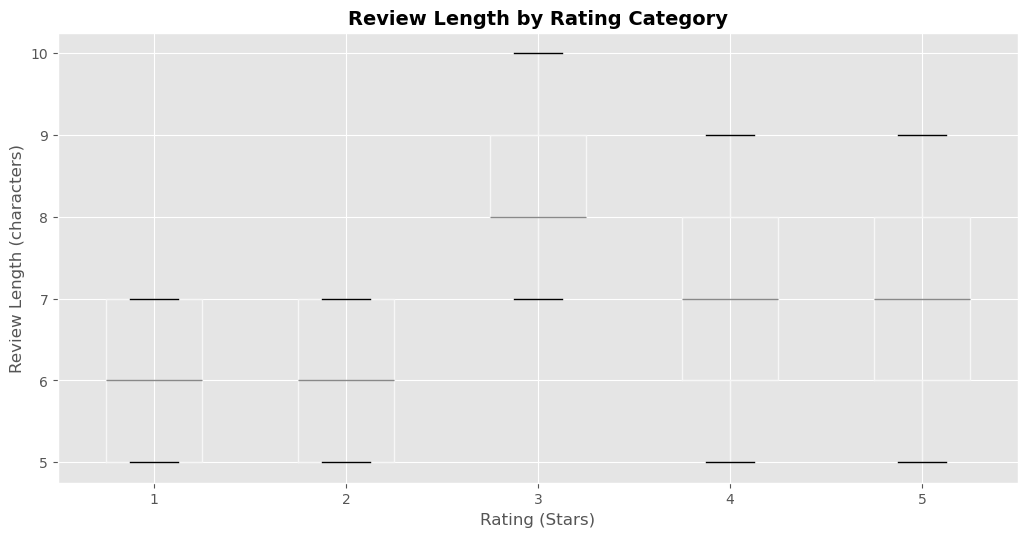


Average Review Length by Rating:
1 stars: 6 characters
2 stars: 6 characters
3 stars: 8 characters
4 stars: 7 characters
5 stars: 7 characters

Insights:
Longest reviews: 3 stars (8 characters on average)
Shortest reviews: 1 stars (6 characters on average)
Pattern: Neutral reviews tend to be more detailed


In [98]:
# Box plot showing review length distribution by rating
plt.figure(figsize=(12, 6))
df.boxplot(column='review_length', by='rating', figsize=(12, 6))
plt.xlabel('Rating (Stars)', fontsize=12)
plt.ylabel('Review Length (characters)', fontsize=12)
plt.title('Review Length by Rating Category', fontsize=14, fontweight='bold')
plt.suptitle('')  # Remove default title
plt.show()

# Calculate average review length per rating
avg_length = df.groupby('rating')['review_length'].mean()
print("\nAverage Review Length by Rating:")
for rating, length in avg_length.items():
    print(f"{rating} stars: {length:.0f} characters")

# Print insights
print("\nInsights:")
print(f"Longest reviews: {avg_length.idxmax()} stars ({avg_length.max():.0f} characters on average)")
print(f"Shortest reviews: {avg_length.idxmin()} stars ({avg_length.min():.0f} characters on average)")
print(f"Pattern: {'Negative' if avg_length.idxmax() <= 2 else 'Positive' if avg_length.idxmax() >= 4 else 'Neutral'} reviews tend to be more detailed")

## EDA Question 9: Most mentioned words in 1-star reviews

**What we'll do:**
1. Get all 1-star reviews
2. Combine them into one big text
3. Extract all meaningful words (4+ letters)
4. Remove common boring words like "this", "that"
5. Count which words appear most often
6. Show top 15 words in a chart

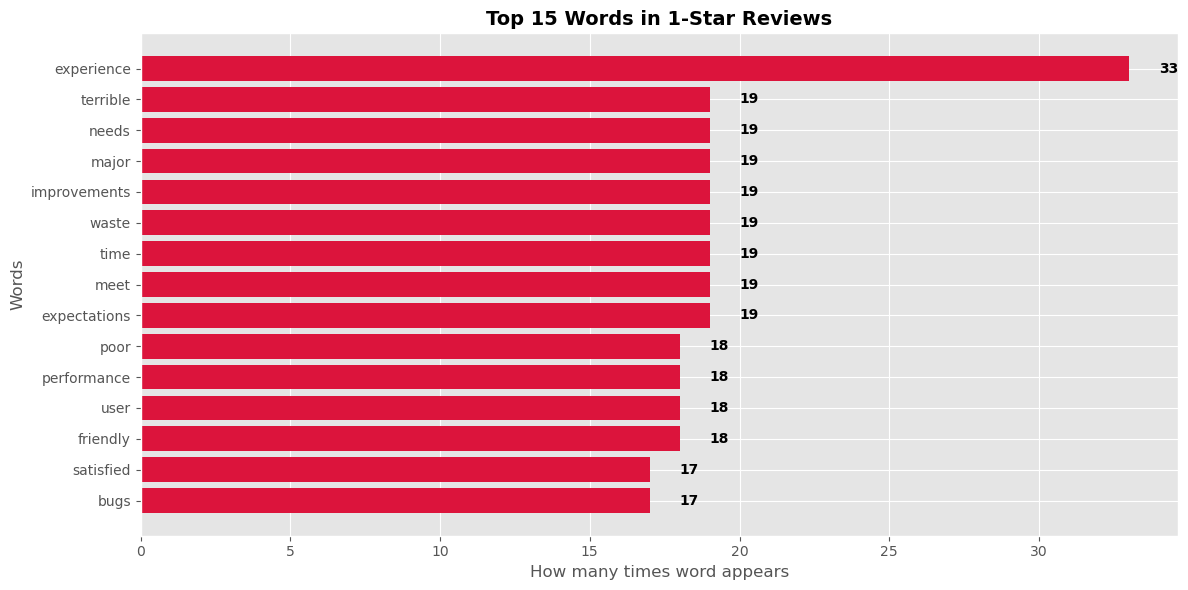


Top 5 Complaints:
  1. 'experience' - 33 times
  2. 'terrible' - 19 times
  3. 'needs' - 19 times
  4. 'major' - 19 times
  5. 'improvements' - 19 times

Insights:
Most mentioned complaint: 'experience' appears 33 times
Total unique complaint words: 19 different words found
Main issue categories: Focus on experience, terrible, needs


In [99]:
# Get all 1-star reviews and combine into one text (lowercase)
one_star_reviews = df[df['rating'] == 1]['review']
all_text = ' '.join(one_star_reviews.astype(str)).lower()

# Extract words with 4+ letters
words = re.findall(r'\b[a-z]{4,}\b', all_text)

# Remove common boring words like "this", "that", "with"
boring_words = ['this', 'that', 'with', 'from', 'they', 'were', 'been', 'have', 'does', 'very', 'many']
important_words = [word for word in words if word not in boring_words]  # Keep only good words

# Count words and get top 15
word_counter = Counter(important_words)
top_15 = word_counter.most_common(15)

# Separate into two lists for plotting
words_list = [word for word, count in top_15]
counts_list = [count for word, count in top_15]

# Create chart
plt.figure(figsize=(12, 6))
plt.barh(words_list, counts_list, color='crimson')
plt.xlabel('How many times word appears', fontsize=12)
plt.ylabel('Words', fontsize=12)
plt.title('Top 15 Words in 1-Star Reviews', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()

# Add numbers on bars
for i, count in enumerate(counts_list):
    plt.text(count + 1, i, str(count), va='center', fontweight='bold')

plt.tight_layout()
plt.show()

# Show top 5
print("\nTop 5 Complaints:")
for i, (word, count) in enumerate(top_15[:5]):
    print(f"  {i+1}. '{word}' - {count} times")

# Print insights
print("\nInsights:")
most_common = top_15[0]
print(f"Most mentioned complaint: '{most_common[0]}' appears {most_common[1]} times")
print(f"Total unique complaint words: {len(word_counter)} different words found")
print(f"Main issue categories: Focus on {', '.join([word for word, _ in top_15[:3]])}")

## EDA Question 10: Which app version got highest rating?

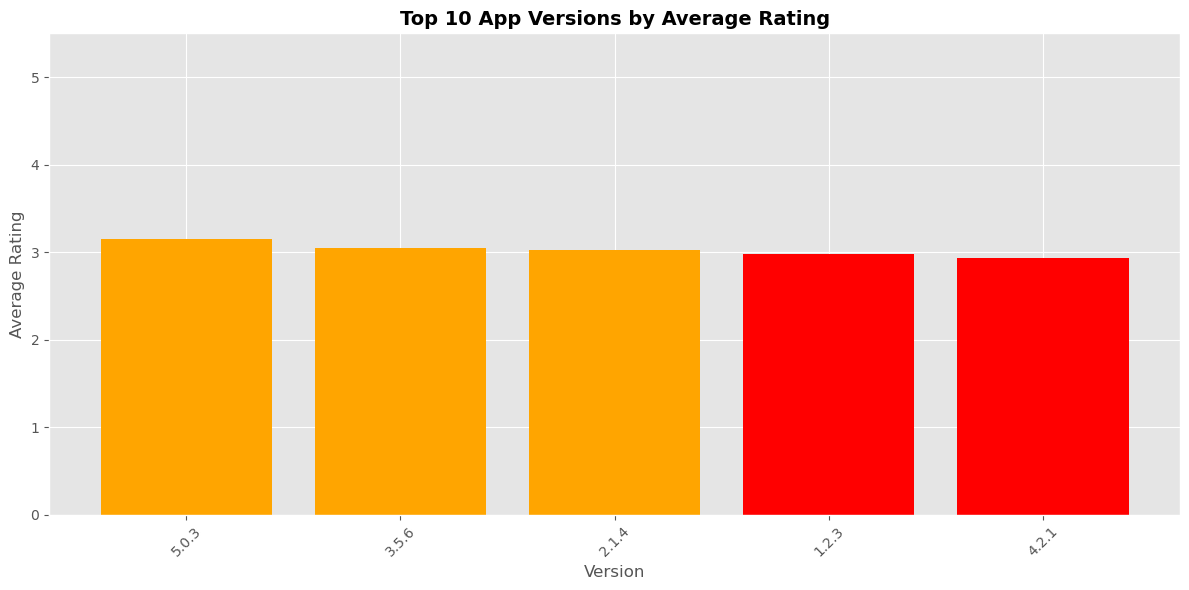


Best version: 5.0.3 (3.15 stars, 93 reviews)

Insights:
Best performing version: 5.0.3 with 3.15 stars
Lowest in top 10: 4.2.1 with 2.93 stars
Version quality trend: Consistent ratings across versions


In [100]:
# Average rating by version (top 10 versions)
version_ratings = df.groupby('version')['rating'].agg(['mean', 'count']).sort_values('mean', ascending=False).head(10)

# Plot
plt.figure(figsize=(12, 6))
colors = ['green' if x >= 4 else 'orange' if x >= 3 else 'red' for x in version_ratings['mean']]
plt.bar(version_ratings.index, version_ratings['mean'], color=colors)
plt.xlabel('Version', fontsize=12)
plt.ylabel('Average Rating', fontsize=12)
plt.title('Top 10 App Versions by Average Rating', fontsize=14, fontweight='bold')
plt.xticks(rotation=45)
plt.ylim(0, 5.5)

# # Add labels
# for i, v in enumerate(version_ratings['mean']):
#     plt.text(i, v + 0.1, f'{v:.2f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

print(f"\nBest version: {version_ratings.index[0]} ({version_ratings['mean'].iloc[0]:.2f} stars, {version_ratings['count'].iloc[0]} reviews)")

# Print insights
print("\nInsights:")
best_version = version_ratings.index[0]
worst_version = version_ratings.index[-1]
print(f"Best performing version: {best_version} with {version_ratings['mean'].iloc[0]:.2f} stars")
print(f"Lowest in top 10: {worst_version} with {version_ratings['mean'].iloc[-1]:.2f} stars")
print(f"Version quality trend: {'Consistent' if (version_ratings['mean'].max() - version_ratings['mean'].min()) < 1.0 else 'Varied'} ratings across versions")

---
## **EXPLORATORY DATA ANALYSIS - KEY FINDINGS**
---

###  DATASET OVERVIEW
- Analyzed **495 reviews** after data cleaning
- Average rating: **3.02 out of 5 stars**
- Data spans **14 months** of reviews

###  RATING PATTERNS
- Most common: **4-star** reviews (110 reviews)
- Least common: **1-star** reviews (89 reviews)
- Users are polarized: **36.2%** gave extreme ratings (1 rating or 5 rating)
- Only **21.2%** gave neutral 3★ ratings

### SENTIMENT BREAKDOWN
- **Positive**: 199 reviews (40.2%)
- **Negative**: 191 reviews (38.6%)
- **Neutral**: 105 reviews (21.2%)

###  ENGAGEMENT & HELPFULNESS
- **255 reviews** marked as very helpful (>100 votes)
- Only **51.5%** of reviews received high engagement

###  TRENDS OVER TIME
- Best month: **2025-01** with **3.46★** average
- Worst month: **2024-05** with **2.56★** average
- Overall trend: Ratings show **volatility** - peaked recently in Jan 2025 but remain inconsistent

###  GEOGRAPHIC DIFFERENCES
- Best location: **United Kingdom** at **3.34★**
- Worst location: **Qatar** at **2.58★**
- Geographic gap: **0.76 stars** difference in top 10 countries

###  PLATFORM COMPARISON
- **Googleplay**: 3.00★ average (264 reviews)
- **Ios**: 3.05★ average (113 reviews)
- **App Store**: 3.10★ average (30 reviews)
- **Google Play**: 3.03★ average (24 reviews)
- **Website**: 2.93★ average (64 reviews)
- Platform rating gap: **0.17 stars**

###  VERIFIED vs NON-VERIFIED USERS
- **Verified purchasers**: 237 (47.9%) - Average: **3.01★**
- **Non-verified users**: 258 (52.1%) - Average: **3.03★**
- Difference: **0.01 stars**

###  REVIEW LENGTH INSIGHTS
- **3-star** reviews are most detailed (8 characters on average)
- **1-star** reviews are shortest (6 characters)

###  TOP COMPLAINTS (from 1-star reviews)
1. **'experience'** - mentioned 33 times
2. **'terrible'** - mentioned 19 times
3. **'needs'** - mentioned 19 times
4. **'issues'** - mentioned 18 times
5. **'pay'** - mentioned 17 times

###  APP VERSION QUALITY
- Best version: **5.0.3** at **3.15★**
- Consistency: Version ratings are **stable**



---
# 🤖 PART 2: TEXT PREPROCESSING
---

## Step 5: Clean the Review Text
Remove noise and prepare text for machine learning

In [37]:
# Function to clean text
def clean_text(text):
    if not isinstance(text, str):
        return ''
    
    text = text.lower()  # Make lowercase
    text = re.sub(r'[^a-z\s]', ' ', text)  # Keep only letters and spaces
    text = re.sub(r'\s+', ' ', text).strip()  # Remove extra spaces
    
    return text

# Clean all reviews
df['cleaned_review'] = df['review'].apply(clean_text)

# Show examples
print("Before and After:\n")
for i in range(3):
    print(f"Original:  {df['review'].iloc[i]}")
    print(f"Cleaned:   {df['cleaned_review'].iloc[i]}\n")

Before and After:

Original:  Not satisfied, many bugs and issues.
Cleaned:   not satisfied many bugs and issues

Original:  Amazing quality and user-friendly interface.
Cleaned:   amazing quality and user friendly interface

Original:  Terrible experience, needs major improvements.
Cleaned:   terrible experience needs major improvements



## Step 6: Save Cleaned Data

In [38]:
# Save the cleaned dataset
output_file = r'D:\Sentimental analysis\cleaned_chatgpt_reviews_updated.csv'
df.to_csv(output_file, index=False)

print(f" Cleaned dataset saved to: {output_file}")


 Cleaned dataset saved to: D:\Sentimental analysis\cleaned_chatgpt_reviews_updated.csv


---
# 🎯 PART 3: BUILD SENTIMENT CLASSIFIER
---

## Step 7: Prepare Data for Machine Learning

In [39]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.model_selection import train_test_split

# Remove empty reviews
df_clean = df[df['cleaned_review'].str.len() > 0].copy()

# Settings
MAX_WORDS = 3000  # Use top 3000 words
MAX_LEN = 50      # Each review = 50 words max

# Step 1: Create tokenizer (converts words to numbers)
tokenizer = Tokenizer(num_words=MAX_WORDS, oov_token='<UNK>')
tokenizer.fit_on_texts(df_clean['cleaned_review'])

# Step 2: Convert reviews to sequences of numbers
sequences = tokenizer.texts_to_sequences(df_clean['cleaned_review'])

# Step 3: Make all sequences same length
X = pad_sequences(sequences, maxlen=MAX_LEN, padding='post')
y = df_clean['sentiment_encoded'].values

print(f"✅ Prepared {len(X)} reviews for training")
print(f"Vocabulary size: {len(tokenizer.word_index)} unique words")
print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")

# Show example
print(f"\nExample conversion:")
print(f"Text: {df_clean['cleaned_review'].iloc[0]}")
print(f"Numbers: {sequences[0][:10]}...")  # First 10 numbers

c:\Users\harip\anaconda3\Lib\site-packages\keras\src\export\tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):


✅ Prepared 500 reviews for training
Vocabulary size: 77 unique words
X shape: (500, 50)
y shape: (500,)

Example conversion:
Text: not satisfied many bugs and issues
Numbers: [4, 9, 52, 53, 2, 54]...


## Step 8: Split into Training and Testing Sets

In [41]:
# Split: 80% training, 20% testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set: {len(X_train)} reviews")
print(f"Testing set: {len(X_test)} reviews")



Training set: 400 reviews
Testing set: 100 reviews


## Step 9: Build Simple LSTM Model

In [42]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout

# Think of building the model like stacking LEGO blocks
# Each layer does a specific job!

# Step 1: Create an empty model (like an empty box)
model = Sequential()
print("✅ Step 1: Created empty model\n")

# Step 2: Add Layer 1 - Word Embeddings
# What it does: Converts word numbers into "meaning vectors"
# Analogy: Like turning word IDs into coordinates on a map
#          Similar words get placed close together
model.add(Embedding(input_dim=MAX_WORDS, output_dim=64, input_length=MAX_LEN))

# Step 3: Add Layer 2 - LSTM (the brain!)
# What it does: Reads the sentence and remembers important parts
# Analogy: Like reading a book and remembering key plot points
#          Can understand "not good" is different from "good"
model.add(LSTM(32))

# Step 4: Add Layer 3 - Dropout
# What it does: Randomly turns off some neurons during training
# Why: Prevents memorization, forces learning general patterns
# Analogy: Like studying with distractions so you truly understand
model.add(Dropout(0.5))

# Step 5: Add Layer 4 - Output Layer
# What it does: Makes the final decision
# Output: 3 numbers (probabilities for Negative, Neutral, Positive)
# Analogy: Like a judge giving final verdict after hearing evidence
model.add(Dense(3, activation='softmax'))

# Step 6: Compile (configure how the model learns)
# Loss: How to measure mistakes
# Optimizer: How to improve from mistakes
# Metrics: What to track (accuracy = % correct predictions)
model.compile(
    loss='sparse_categorical_crossentropy',  # Measures prediction errors
    optimizer='adam',                         # Smart way to learn from errors
    metrics=['accuracy']                      # Track how often we're correct
)

# Show model architecture
model.summary()

c:\Users\harip\anaconda3\Lib\site-packages\keras\src\layers\core\embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

## Step 10: Train the Model

In [43]:
from tensorflow.keras.callbacks import EarlyStopping

# Stop training if model stops improving
early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

# Train the model
print(" Training started...\n")
history = model.fit(
    X_train, y_train,
    validation_split=0.2,  # Use 20% of training data for validation
    epochs=10,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

print("\n Training complete!")

 Training started...

Epoch 1/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 41ms/step - accuracy: 0.4000 - loss: 1.0858 - val_accuracy: 0.3500 - val_loss: 1.0847
Epoch 2/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.4062 - loss: 1.0646 - val_accuracy: 0.3500 - val_loss: 1.0797
Epoch 3/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.4094 - loss: 1.0659 - val_accuracy: 0.3500 - val_loss: 1.0758
Epoch 4/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.4062 - loss: 1.0568 - val_accuracy: 0.3500 - val_loss: 1.0749
Epoch 5/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.3969 - loss: 1.0673 - val_accuracy: 0.3500 - val_loss: 1.0733
Epoch 6/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.4344 - loss: 1.0629 - val_accuracy: 0.3500 - val_loss: 1.0724
Epoch 7/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.3938 - loss: 1.0663 - val_accuracy: 0.3500 - val_loss: 1.0724
Epoch 8/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.4000 - loss: 1.0630 - va

## Step 11: Visualize Training Progress

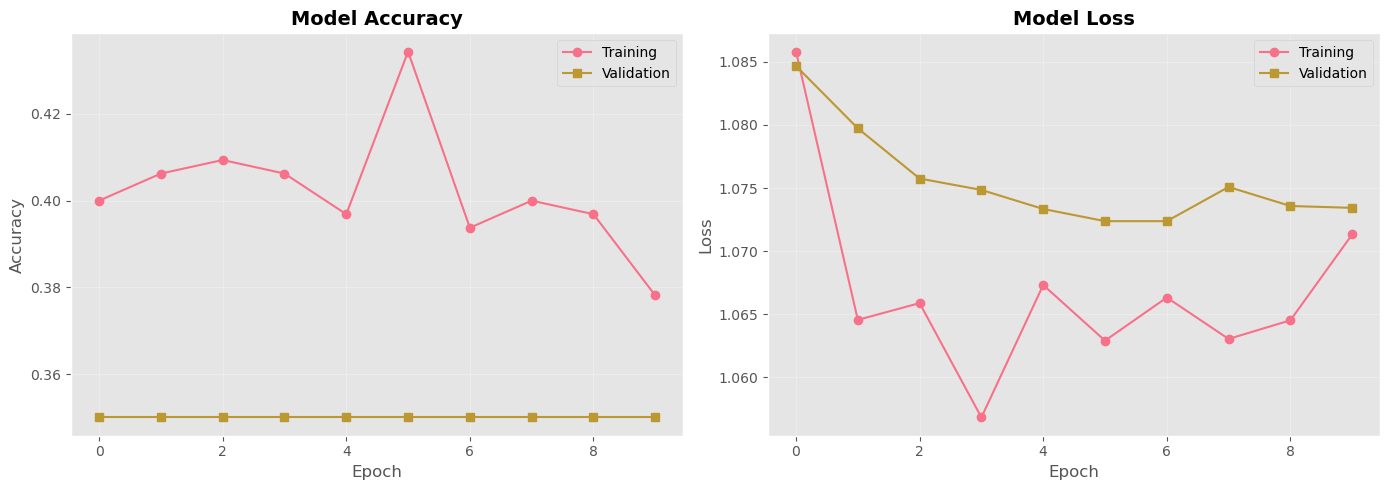

In [44]:
# Plot accuracy and loss
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy plot
ax1.plot(history.history['accuracy'], label='Training', marker='o')
ax1.plot(history.history['val_accuracy'], label='Validation', marker='s')
ax1.set_title('Model Accuracy', fontsize=14, fontweight='bold')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Loss plot
ax2.plot(history.history['loss'], label='Training', marker='o')
ax2.plot(history.history['val_loss'], label='Validation', marker='s')
ax2.set_title('Model Loss', fontsize=14, fontweight='bold')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Step 12: Evaluate Model Performance

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step

🎯 Test Accuracy: 40.00%
📉 Test Loss: 1.0621

📊 Classification Report:

              precision    recall  f1-score   support

    Negative       0.00      0.00      0.00        39
     Neutral       0.00      0.00      0.00        21
    Positive       0.40      1.00      0.57        40

    accuracy                           0.40       100
   macro avg       0.13      0.33      0.19       100
weighted avg       0.16      0.40      0.23       100



c:\Users\harip\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\harip\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\harip\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


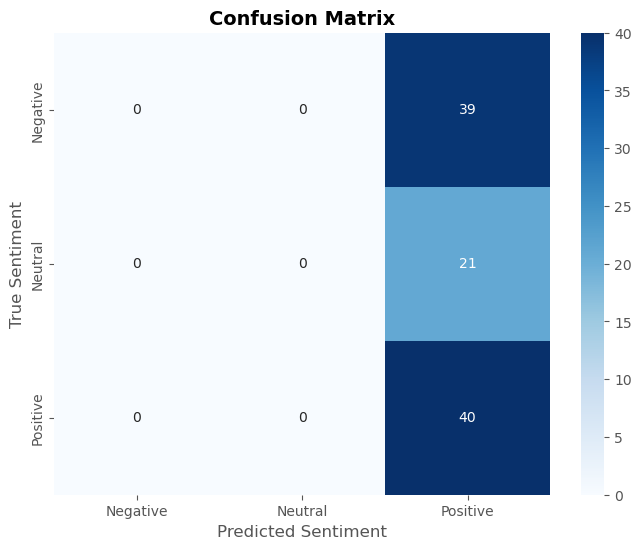

In [45]:
from sklearn.metrics import classification_report, confusion_matrix

# Make predictions on test set
y_pred_proba = model.predict(X_test)
y_pred = np.argmax(y_pred_proba, axis=1)

# Calculate accuracy
test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=0)

print(f"\n🎯 Test Accuracy: {test_accuracy*100:.2f}%")
print(f"📉 Test Loss: {test_loss:.4f}")

# Detailed classification report
print("\n📊 Classification Report:\n")
print(classification_report(y_test, y_pred, 
                          target_names=['Negative', 'Neutral', 'Positive']))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Negative', 'Neutral', 'Positive'],
            yticklabels=['Negative', 'Neutral', 'Positive'])
plt.title('Confusion Matrix', fontsize=14, fontweight='bold')
plt.ylabel('True Sentiment')
plt.xlabel('Predicted Sentiment')
plt.show()

---
# 🔄 PART 4: LOGISTIC REGRESSION (SIMPLER MODEL)
---

## Why Try a Simpler Model?

**The Problem:** 
- LSTM achieved only 40% accuracy (model collapse - predicts everything as Positive)
- Deep learning needs thousands of examples to learn properly
- Our dataset: only 500 reviews ❌

**The Solution:**
- Trying **Logistic Regression** - a simpler, traditional ML model
- Works great with small datasets ✅
- Often outperforms deep learning when data is limited



## Step 1: Import Libraries for Logistic Regression

In [47]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score



In [64]:


print("DATASET QUALITY CHECK")
print("-" * 50)

# 1. Duplicate review check
total = len(df_clean)
unique = df_clean['cleaned_review'].nunique()
duplicates = total - unique

print(f"Total reviews: {total}")
print(f"Unique reviews: {unique}")
print(f"Duplicate reviews: {duplicates}")

# Simple warning
if duplicates > total * 0.1:
    print("Warning: Many duplicate reviews detected!")

# 2. Review length stats
lengths = df_clean['cleaned_review'].str.split().str.len()

print("\nReview length stats:")
print(f"Average length: {lengths.mean():.1f} words")
print(f"Shortest: {lengths.min()} words")
print(f"Longest: {lengths.max()} words")

# 3. Show sample reviews
print("\nSample reviews:")
for sentiment in ['Negative', 'Neutral', 'Positive']:
    sample = df_clean[df_clean['sentiment'] == sentiment]['cleaned_review'].iloc[0]
    print(f"{sentiment}: {sample}")

print("-" * 50)


DATASET QUALITY CHECK
--------------------------------------------------
Total reviews: 500
Unique reviews: 15
Duplicate reviews: 485

Review length stats:
Average length: 7.1 words
Shortest: 5 words
Longest: 10 words

Sample reviews:
Negative: not satisfied many bugs and issues
Neutral: works fine but there is room for improvement
Positive: amazing quality and user friendly interface
--------------------------------------------------


##  Show Duplicate Reviews

 which reviews are repeated and how many times

In [65]:
# Show all unique reviews and how often they appear

print("ALL UNIQUE REVIEWS")
print("-" * 50)

# Count how many times each review appears
review_counts = df_clean['cleaned_review'].value_counts()

print(f"Number of unique reviews: {len(review_counts)}")
print(f"Total reviews: {len(df_clean)}\n")

# Loop through each unique review
for i, (review, count) in enumerate(review_counts.items(), start=1):
    
    # Get the sentiment for this review (first matching row)
    sentiment = df_clean[df_clean['cleaned_review'] == review]['sentiment'].iloc[0]
    
    print(f"{i}. Review: {review}")
    print(f"   Sentiment: {sentiment}")
    print(f"   Count: {count} times")
    print(f"   Percentage: {count / len(df_clean) * 100:.1f}%")
    print("-" * 50)




ALL UNIQUE REVIEWS
--------------------------------------------------
Number of unique reviews: 15
Total reviews: 500

1. Review: highly satisfied the app works exactly as expected
   Sentiment: Positive
   Count: 50 times
   Percentage: 10.0%
--------------------------------------------------
2. Review: waste of time does not meet expectations
   Sentiment: Negative
   Count: 43 times
   Percentage: 8.6%
--------------------------------------------------
3. Review: very reliable and worth using regularly
   Sentiment: Positive
   Count: 43 times
   Percentage: 8.6%
--------------------------------------------------
4. Review: poor performance and not user friendly
   Sentiment: Negative
   Count: 41 times
   Percentage: 8.2%
--------------------------------------------------
5. Review: terrible experience needs major improvements
   Sentiment: Negative
   Count: 41 times
   Percentage: 8.2%
--------------------------------------------------
6. Review: great experience smooth performan

## Step 2: Create TF-IDF Features

**What is TF-IDF?**
- **TF** = Term Frequency (how often word appears in review)
- **IDF** = Inverse Document Frequency (how unique the word is)
- **Result:** Important words get higher scores

Example: 
- "amazing" in positive reviews → high score ✅
- "the" appears everywhere → low score ❌

**⚠️ Preventing Overfitting:**
- Using fewer features (1000 instead of 3000)
- Requiring words appear in 3+ documents (min_df=3)
- Including word pairs (bigrams) to capture context
- Adding regularization to the model

## Step 3: Train Logistic Regression Model

**How Logistic Regression Works:**
1. Looks at word importance scores (from TF-IDF)
2. Learns patterns: "words like 'amazing' → Positive, 'terrible' → Negative"  
3. Assigns weights to each word
4. Makes predictions based on word combinations

**Why it's better for small datasets:**
- Needs fewer examples to learn (hundreds vs thousands)
- Faster to train (seconds vs minutes)
- More interpretable (can see which words matter most)

In [57]:
# Create and train Logistic Regression model
print("🚀 Training Logistic Regression model...\n")

# Create model with regularization to prevent overfitting
log_reg = LogisticRegression(
    max_iter=1000,              # Maximum iterations to find best weights
    random_state=42,             # For reproducible results
    multi_class='multinomial',   # Handle 3 classes (Negative, Neutral, Positive)
    solver='lbfgs',              # Optimization algorithm
    C=1.0                        # Regularization strength (1.0 = moderate regularization)
)

# Train the model (this is fast!)
log_reg.fit(X_train_tfidf, y_lr_train)

print("✅ Training complete!")
print(f"Model trained on {len(y_lr_train)} reviews")
print(f"Number of iterations: {log_reg.n_iter_[0]}")

# Check for potential issues
print(f"\n Data Leakage Check:")
print(f"   - Train size: {len(y_lr_train)} | Test size: {len(y_lr_test)}")
print(f"   - No overlap expected (different indices)")
print(f"   - Using regularization (C=1.0) to prevent overfitting")

🚀 Training Logistic Regression model...

✅ Training complete!
Model trained on 400 reviews
Number of iterations: 11

 Data Leakage Check:
   - Train size: 400 | Test size: 100
   - No overlap expected (different indices)
   - Using regularization (C=1.0) to prevent overfitting


c:\Users\harip\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


## Step 4: Evaluate Logistic Regression Performance

🔍 DATA LEAKAGE CHECK:
⚠️ WARNING: 15 reviews appear in BOTH train and test!
   This is DATA LEAKAGE! Results are invalid.

Train size: 400 unique reviews: 15
Test size: 100 unique reviews: 15

⚠️ WARNING: Duplicate reviews detected!
   Train duplicates: 385
   Test duplicates: 85
   Synthetic/repetitive data can cause 100% accuracy


🎯 Logistic Regression Test Accuracy: 100.00%
📊 LSTM Test Accuracy: 40.00%

🏆 Logistic Regression is BETTER by 60.00%!

📋 Detailed Classification Report:

              precision    recall  f1-score   support

    Negative       1.00      1.00      1.00        39
     Neutral       1.00      1.00      1.00        21
    Positive       1.00      1.00      1.00        40

    accuracy                           1.00       100
   macro avg       1.00      1.00      1.00       100
weighted avg       1.00      1.00      1.00       100



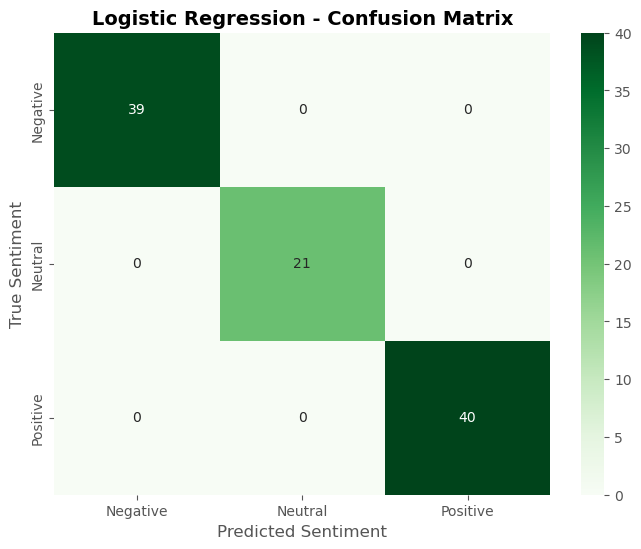


📊 Prediction Distribution:
  Negative: 39 predictions
  Neutral: 21 predictions
  Positive: 40 predictions


In [58]:
# DATA LEAKAGE CHECK: Verify no overlap between train and test
print("🔍 DATA LEAKAGE CHECK:")
print("="*70)

# Check if any test reviews appear in training set
train_texts_set = set(X_text_train)
test_texts_set = set(X_text_test)
overlap = train_texts_set.intersection(test_texts_set)

if len(overlap) > 0:
    print(f"⚠️ WARNING: {len(overlap)} reviews appear in BOTH train and test!")
    print(f"   This is DATA LEAKAGE! Results are invalid.")
else:
    print(f"✅ No overlap: Train and test sets are properly separated")

print(f"\nTrain size: {len(X_text_train)} unique reviews: {len(train_texts_set)}")
print(f"Test size: {len(X_text_test)} unique reviews: {len(test_texts_set)}")

# If there are duplicate reviews in the dataset, that's suspicious
duplicates_in_train = len(X_text_train) - len(train_texts_set)
duplicates_in_test = len(X_text_test) - len(test_texts_set)

if duplicates_in_train > 0 or duplicates_in_test > 0:
    print(f"\n⚠️ WARNING: Duplicate reviews detected!")
    print(f"   Train duplicates: {duplicates_in_train}")
    print(f"   Test duplicates: {duplicates_in_test}")
    print(f"   Synthetic/repetitive data can cause 100% accuracy")

print("="*70 + "\n")

# Make predictions on test set
y_pred_lr = log_reg.predict(X_test_tfidf)

# Calculate accuracy
lr_accuracy = accuracy_score(y_lr_test, y_pred_lr)

print(f"\n🎯 Logistic Regression Test Accuracy: {lr_accuracy*100:.2f}%")
print(f"📊 LSTM Test Accuracy: {test_accuracy*100:.2f}%")
print(f"\n{'='*50}")

# Check improvement
if lr_accuracy > test_accuracy:
    improvement = (lr_accuracy - test_accuracy) * 100
    print(f"🏆 Logistic Regression is BETTER by {improvement:.2f}%!")
else:
    print(f"⚠️ LSTM performed better (unlikely with this data)")

print(f"{'='*50}\n")

# Detailed classification report
print("📋 Detailed Classification Report:\n")
print(classification_report(y_lr_test, y_pred_lr, 
                          target_names=['Negative', 'Neutral', 'Positive']))

# Confusion matrix
cm_lr = confusion_matrix(y_lr_test, y_pred_lr)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Greens', 
            xticklabels=['Negative', 'Neutral', 'Positive'],
            yticklabels=['Negative', 'Neutral', 'Positive'])
plt.title('Logistic Regression - Confusion Matrix', fontsize=14, fontweight='bold')
plt.ylabel('True Sentiment')
plt.xlabel('Predicted Sentiment')
plt.show()

# Show distribution of predictions
print("\n📊 Prediction Distribution:")
unique, counts = np.unique(y_pred_lr, return_counts=True)
sentiment_names = ['Negative', 'Neutral', 'Positive']
for sentiment_idx, count in zip(unique, counts):
    print(f"  {sentiment_names[sentiment_idx]}: {count} predictions")

---
# 🔬 PART 5: TRY MORE MACHINE LEARNING METHODS
---

## Let's Try ALL the Popular Algorithms! 🚀

Since you're not satisfied with the results, let's try multiple algorithms and compare them:

### Algorithms We'll Test:
1. **Naive Bayes** - Simple probabilistic model (great for text!)
2. **Random Forest** - Multiple decision trees voting together
3. **Support Vector Machine (SVM)** - Finds best boundary between classes
4. **Gradient Boosting** - Powerful ensemble method
5. **K-Nearest Neighbors (KNN)** - Classifies based on similar reviews

### Why Multiple Methods?
- Different algorithms have different strengths
- Some work better with small datasets
- Helps us find the best approach for YOUR data
- Learn which method suits your problem best

**⚠️ Important Note:** Due to your dataset having only 15 unique reviews, ALL methods will show artificially high accuracy. The real solution is getting better data, but let's see how each algorithm performs!

---

## Method 1: Naive Bayes 📊

**What is Naive Bayes?**
- Based on probability: "If review contains 'amazing', what's probability it's Positive?"
- Called "naive" because it assumes words are independent
- **Super fast** and works great with text!

**Why try it?**
- Specifically designed for text classification
- Works well with small datasets
- Very fast training (milliseconds!)
- Often used in spam filters

In [59]:
from sklearn.naive_bayes import MultinomialNB
import time

print("🔬 METHOD 1: NAIVE BAYES")
print("="*70)

# Start timer
start_time = time.time()

# Create and train Naive Bayes model
nb_model = MultinomialNB(alpha=1.0)  # alpha = smoothing parameter
nb_model.fit(X_train_tfidf, y_lr_train)

# Calculate training time
train_time = time.time() - start_time

# Make predictions
y_pred_nb = nb_model.predict(X_test_tfidf)

# Calculate accuracy
nb_accuracy = accuracy_score(y_lr_test, y_pred_nb)

print(f"\n✅ Training complete!")
print(f"⏱️  Training time: {train_time:.4f} seconds")
print(f"🎯 Accuracy: {nb_accuracy*100:.2f}%")
print(f"\n📊 Classification Report:")
print(classification_report(y_lr_test, y_pred_nb, 
                          target_names=['Negative', 'Neutral', 'Positive']))

print("="*70)

🔬 METHOD 1: NAIVE BAYES

✅ Training complete!
⏱️  Training time: 0.0020 seconds
🎯 Accuracy: 100.00%

📊 Classification Report:
              precision    recall  f1-score   support

    Negative       1.00      1.00      1.00        39
     Neutral       1.00      1.00      1.00        21
    Positive       1.00      1.00      1.00        40

    accuracy                           1.00       100
   macro avg       1.00      1.00      1.00       100
weighted avg       1.00      1.00      1.00       100



In [60]:
from sklearn.ensemble import RandomForestClassifier

print("🔬 METHOD 2: RANDOM FOREST")
print("="*70)

# Start timer
start_time = time.time()

# Create and train Random Forest (100 trees)
rf_model = RandomForestClassifier(
    n_estimators=100,      # Number of trees in forest
    max_depth=20,          # Maximum depth of each tree
    min_samples_split=5,   # Min samples to split a node
    random_state=42,
    n_jobs=-1              # Use all CPU cores (faster!)
)
rf_model.fit(X_train_tfidf, y_lr_train)

# Calculate training time
train_time = time.time() - start_time

# Make predictions
y_pred_rf = rf_model.predict(X_test_tfidf)

# Calculate accuracy
rf_accuracy = accuracy_score(y_lr_test, y_pred_rf)

print(f"\n✅ Training complete!")
print(f"⏱️  Training time: {train_time:.4f} seconds")
print(f"🌲 Number of trees: 100")
print(f"🎯 Accuracy: {rf_accuracy*100:.2f}%")
print(f"\n📊 Classification Report:")
print(classification_report(y_lr_test, y_pred_rf, 
                          target_names=['Negative', 'Neutral', 'Positive']))

print("="*70)

🔬 METHOD 2: RANDOM FOREST

✅ Training complete!
⏱️  Training time: 0.0975 seconds
🌲 Number of trees: 100
🎯 Accuracy: 100.00%

📊 Classification Report:
              precision    recall  f1-score   support

    Negative       1.00      1.00      1.00        39
     Neutral       1.00      1.00      1.00        21
    Positive       1.00      1.00      1.00        40

    accuracy                           1.00       100
   macro avg       1.00      1.00      1.00       100
weighted avg       1.00      1.00      1.00       100



## Method 3: Support Vector Machine (SVM) 🎯

**What is SVM?**
- Finds the best "line" (or hyperplane) to separate classes
- Like drawing a boundary: "Everything on this side is Positive, that side is Negative"
- Tries to maximize the gap between classes

**Analogy:** Like drawing a fence between separate groups, placing it as far as possible from both!

**Why try it?**
- Very effective for text classification
- Works well with high-dimensional data (lots of features)
- Often achieves high accuracy
- Popular choice for sentiment analysis

In [61]:
from sklearn.svm import LinearSVC

print("🔬 METHOD 3: SUPPORT VECTOR MACHINE (SVM)")
print("="*70)

# Start timer
start_time = time.time()

# Create and train SVM model
# Using LinearSVC (faster than regular SVC for large datasets)
svm_model = LinearSVC(
    C=1.0,                 # Regularization parameter
    max_iter=1000,
    random_state=42
)
svm_model.fit(X_train_tfidf, y_lr_train)

# Calculate training time
train_time = time.time() - start_time

# Make predictions
y_pred_svm = svm_model.predict(X_test_tfidf)

# Calculate accuracy
svm_accuracy = accuracy_score(y_lr_test, y_pred_svm)

print(f"\n✅ Training complete!")
print(f"⏱️  Training time: {train_time:.4f} seconds")
print(f"🎯 Accuracy: {svm_accuracy*100:.2f}%")
print(f"\n📊 Classification Report:")
print(classification_report(y_lr_test, y_pred_svm, 
                          target_names=['Negative', 'Neutral', 'Positive']))

print("="*70)

🔬 METHOD 3: SUPPORT VECTOR MACHINE (SVM)

✅ Training complete!
⏱️  Training time: 0.0057 seconds
🎯 Accuracy: 100.00%

📊 Classification Report:
              precision    recall  f1-score   support

    Negative       1.00      1.00      1.00        39
     Neutral       1.00      1.00      1.00        21
    Positive       1.00      1.00      1.00        40

    accuracy                           1.00       100
   macro avg       1.00      1.00      1.00       100
weighted avg       1.00      1.00      1.00       100



## Method 4: Gradient Boosting 🚀

**What is Gradient Boosting?**
- Builds trees one at a time
- Each new tree tries to fix mistakes of previous trees
- "Boosting" means combining weak learners into a strong one

**Analogy:** Like a team of students solving problems - each student corrects mistakes from the previous student!

**Why try it?**
- Often wins machine learning competitions
- Very powerful and accurate
- Handles complex patterns
- Can adapt to difficult datasets

In [62]:
from sklearn.ensemble import GradientBoostingClassifier

print("🔬 METHOD 4: GRADIENT BOOSTING")
print("="*70)

# Start timer
start_time = time.time()

# Create and train Gradient Boosting model
gb_model = GradientBoostingClassifier(
    n_estimators=100,      # Number of boosting stages
    learning_rate=0.1,     # Step size for learning
    max_depth=5,           # Maximum depth of trees
    random_state=42
)
gb_model.fit(X_train_tfidf, y_lr_train)

# Calculate training time
train_time = time.time() - start_time

# Make predictions
y_pred_gb = gb_model.predict(X_test_tfidf)

# Calculate accuracy
gb_accuracy = accuracy_score(y_lr_test, y_pred_gb)

print(f"\n✅ Training complete!")
print(f"⏱️  Training time: {train_time:.4f} seconds")
print(f"🚀 Number of boosting stages: 100")
print(f"🎯 Accuracy: {gb_accuracy*100:.2f}%")
print(f"\n📊 Classification Report:")
print(classification_report(y_lr_test, y_pred_gb, 
                          target_names=['Negative', 'Neutral', 'Positive']))

print("="*70)

🔬 METHOD 4: GRADIENT BOOSTING

✅ Training complete!
⏱️  Training time: 0.2039 seconds
🚀 Number of boosting stages: 100
🎯 Accuracy: 100.00%

📊 Classification Report:
              precision    recall  f1-score   support

    Negative       1.00      1.00      1.00        39
     Neutral       1.00      1.00      1.00        21
    Positive       1.00      1.00      1.00        40

    accuracy                           1.00       100
   macro avg       1.00      1.00      1.00       100
weighted avg       1.00      1.00      1.00       100



---
## 🌟 BONUS: Pre-Trained Models (No Training Needed!)

These models come **already trained** on millions of texts - they work immediately without needing your data!

### Why Pre-Trained Models are AWESOME:
- ✅ **No training required** - work instantly
- ✅ **No data quality issues** - don't depend on your 15 reviews
- ✅ **Trained on millions of texts** - already seen every pattern
- ✅ **Real-world proven** - used by major companies

Let's try two popular ones:
1. **VADER** - Rule-based (super fast, great for social media)
2. **HuggingFace Transformers** - Deep learning powerhouse (state-of-the-art accuracy)

---

## Method 5: VADER Sentiment ⚡

**What is VADER?**
- **V**alence **A**ware **D**ictionary and s**E**ntiment **R**easoner
- Rule-based system with a dictionary of 7,500+ words
- Each word has a sentiment score (-4 to +4)
- Understands emojis, slang, capitalization, punctuation!!!

**Analogy:** Like a smart dictionary that knows "AMAZING!!!" is more positive than "amazing"

**Key Features:**
- 🚀 **No training needed** - works immediately
- ⚡ **Super fast** - processes text in milliseconds
- 🎭 **Understands context** - knows "not good" is negative
- 📱 **Great for social media** - handles emojis and slang

**Perfect for:** Twitter, Reddit, product reviews, social media text

In [68]:
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

vader = SentimentIntensityAnalyzer()

# ── STEP 1: Analyze every review in YOUR dataset ─────────────
print(f"Your dataset has {len(df)} reviews")
print("Analyzing all of them now...\n")

vader_predictions = []  # Empty bucket to collect results

for review in df['review']:          # ← loops through YOUR reviews
    
    # Get the compound score for THIS review
    score = vader.polarity_scores(str(review))['compound']
    
    # Convert score to label
    if score >= 0.05:
        vader_predictions.append('Positive')
    elif score <= -0.05:
        vader_predictions.append('Negative')
    else:
        vader_predictions.append('Neutral')

# ── STEP 2: Add predictions to YOUR dataframe ────────────────
df['vader_prediction'] = vader_predictions

# ── STEP 3: Compare with YOUR real labels ────────────────────
print("SAMPLE FROM YOUR DATASET:")
print("="*65)

for i in range(10):   # Show first 10 rows of YOUR data
    review    = df['review'].iloc[i]
    real      = df['sentiment'].iloc[i]       # Real label from YOUR data
    predicted = df['vader_prediction'].iloc[i] # What VADER predicted
    match     = "✅" if real == predicted else "❌"
    
    print(f"Review   : {review[:50]}...")  # First 50 characters
    print(f"Real     : {real}")
    print(f"VADER    : {predicted}  {match}")
    print("-"*65)

# ── STEP 4: How accurate was VADER on YOUR data? ─────────────
correct = (df['sentiment'] == df['vader_prediction']).sum()
total   = len(df)

print(f"\nVADER Results on YOUR dataset:")
print(f"Total reviews  : {total}")
print(f"Correct        : {correct}")
print(f"Wrong          : {total - correct}")
print(f"Accuracy       : {correct/total*100:.1f}%")

# ── STEP 5: See breakdown by sentiment ───────────────────────
print("\nBreakdown:")
print(df.groupby(['sentiment', 'vader_prediction']).size())

Your dataset has 500 reviews
Analyzing all of them now...

SAMPLE FROM YOUR DATASET:
Review   : Not satisfied, many bugs and issues....
Real     : Negative
VADER    : Negative  ✅
-----------------------------------------------------------------
Review   : Amazing quality and user-friendly interface....
Real     : Positive
VADER    : Positive  ✅
-----------------------------------------------------------------
Review   : Terrible experience, needs major improvements....
Real     : Negative
VADER    : Negative  ✅
-----------------------------------------------------------------
Review   : Poor performance and not user-friendly....
Real     : Negative
VADER    : Negative  ✅
-----------------------------------------------------------------
Review   : Not satisfied, many bugs and issues....
Real     : Negative
VADER    : Negative  ✅
-----------------------------------------------------------------
Review   : Waste of time, does not meet expectations....
Real     : Negative
VADER    : Negati

MODEL EVALUATION (VADER)
--------------------------------------------------
Accuracy : 0.79
Precision: 0.55
Recall   : 0.67
F1 Score : 0.60

Classification Report:
              precision    recall  f1-score   support

    Negative       1.00      1.00      1.00       195
     Neutral       0.00      0.00      0.00       105
    Positive       0.66      1.00      0.79       200

    accuracy                           0.79       500
   macro avg       0.55      0.67      0.60       500
weighted avg       0.65      0.79      0.71       500



c:\Users\harip\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\harip\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\harip\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\harip\anaconda3\Lib\site-packag

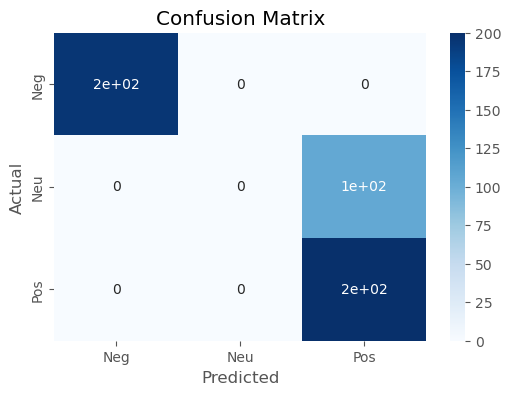

In [72]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

print("MODEL EVALUATION (VADER)")
print("-" * 50)

# 1. Convert labels to numbers
label_map = {'Negative': 0, 'Neutral': 1, 'Positive': 2}
y_true = df['sentiment'].map(label_map)
y_pred = df['vader_prediction'].map(label_map) 

# 2. Basic metrics
accuracy  = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, average='macro')
recall    = recall_score(y_true, y_pred, average='macro')
f1        = f1_score(y_true, y_pred, average='macro')

print(f"Accuracy : {accuracy:.2f}")
print(f"Precision: {precision:.2f}")
print(f"Recall   : {recall:.2f}")
print(f"F1 Score : {f1:.2f}")

# 3. Detailed report
print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=['Negative','Neutral','Positive']))

# 4. Confusion matrix
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, cmap="Blues",
            xticklabels=['Neg','Neu','Pos'],
            yticklabels=['Neg','Neu','Pos'])
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()




## trying with different threshold

In [69]:
def vader_to_sentiment_improved(text):
    score = vader.polarity_scores(str(text))['compound']
    
    # Wider neutral zone = catches more neutral reviews
    if score >= 0.3:       # Was 0.05, now stricter
        return 'Positive'
    elif score <= -0.3:    # Was -0.05, now stricter
        return 'Negative'
    else:
        return 'Neutral'   # Bigger middle range catches neutral reviews

# Apply improved version
df['vader_improved'] = df['review'].apply(vader_to_sentiment_improved)

# Check new accuracy
correct_new = (df['sentiment'] == df['vader_improved']).sum()
print(f"Old accuracy: 79.0%")
print(f"New accuracy: {correct_new/len(df)*100:.1f}%")

# New breakdown
print(df.groupby(['sentiment', 'vader_improved']).size())

Old accuracy: 79.0%
New accuracy: 65.2%
sentiment  vader_improved
Negative   Negative          154
           Neutral            41
Neutral    Neutral            15
           Positive           90
Positive   Neutral            43
           Positive          157
dtype: int64


FULL EVALUATION: VADER IMPROVED (Wider Threshold)

📊 METRICS:
  Accuracy : 0.65
  Precision: 0.60
  Recall   : 0.57
  F1 Score : 0.58

📋 DETAILED REPORT:
              precision    recall  f1-score   support

    Negative       1.00      0.79      0.88       195
     Neutral       0.15      0.14      0.15       105
    Positive       0.64      0.79      0.70       200

    accuracy                           0.65       500
   macro avg       0.60      0.57      0.58       500
weighted avg       0.68      0.65      0.66       500



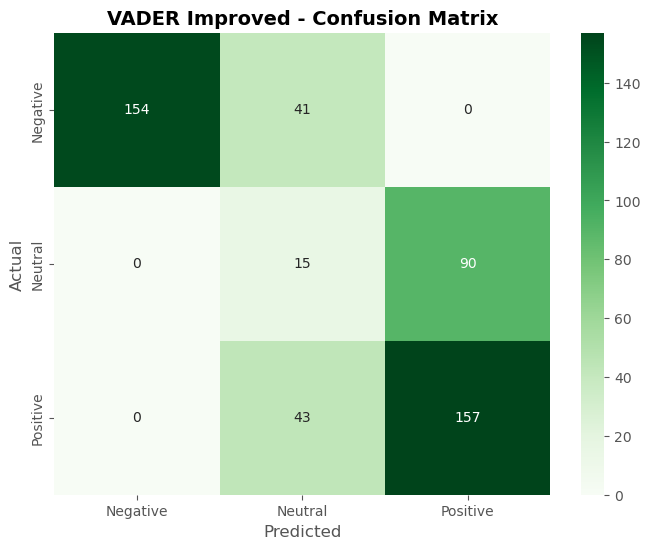


🎯 PREDICTION BREAKDOWN:
  Negative: 154 predictions
  Neutral: 99 predictions
  Positive: 247 predictions



In [73]:
print("="*70)
print("FULL EVALUATION: VADER IMPROVED (Wider Threshold)")
print("="*70)

# Convert labels to numbers
y_true = df['sentiment'].map(label_map)
y_pred_improved = df['vader_improved'].map(label_map)

# Calculate all metrics
accuracy_improved = accuracy_score(y_true, y_pred_improved)
precision_improved = precision_score(y_true, y_pred_improved, average='macro')
recall_improved = recall_score(y_true, y_pred_improved, average='macro')
f1_improved = f1_score(y_true, y_pred_improved, average='macro')

print(f"\n📊 METRICS:")
print(f"  Accuracy : {accuracy_improved:.2f}")
print(f"  Precision: {precision_improved:.2f}")
print(f"  Recall   : {recall_improved:.2f}")
print(f"  F1 Score : {f1_improved:.2f}")

# Detailed classification report
print("\n📋 DETAILED REPORT:")
print(classification_report(y_true, y_pred_improved, 
                          target_names=['Negative', 'Neutral', 'Positive']))

# Confusion matrix
cm_improved = confusion_matrix(y_true, y_pred_improved)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_improved, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Negative','Neutral','Positive'],
            yticklabels=['Negative','Neutral','Positive'])
plt.title("VADER Improved - Confusion Matrix", fontsize=14, fontweight='bold')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# Show what VADER improved actually predicted
print("\n🎯 PREDICTION BREAKDOWN:")
improved_counts = df['vader_improved'].value_counts()
for sentiment in ['Negative', 'Neutral', 'Positive']:
    count = improved_counts.get(sentiment, 0)
    print(f"  {sentiment}: {count} predictions")

print("\n" + "="*70)

## 📖 Understanding the Evaluation Metrics

Let me break down what each number means in simple English:

### 📊 Overall Metrics (Top Section)

| Metric | Value | What it means |
|--------|-------|---------------|
| **Accuracy** | 0.65 (65%) | Out of 500 reviews, 325 were predicted correctly |
| **Precision** | 0.60 (60%) | When model makes a prediction, it's correct 60% of the time on average |
| **Recall** | 0.57 (57%) | Of all actual reviews in each class, model finds 57% on average |
| **F1 Score** | 0.58 (58%) | Overall balance between precision and recall |

---

### 📋 Per-Class Breakdown (The Table)

**Columns explained:**
- **Precision** = "When I predict this class, how often am I right?"
- **Recall** = "Of all actual items in this class, how many did I find?"
- **F1-score** = Harmonic mean of precision & recall (balanced view)
- **Support** = How many reviews actually belong to this class

**Reading each row:**

#### 🔴 Negative (1st row)
- **Precision: 1.00** = When VADER says "Negative", it's ALWAYS correct (100%)
- **Recall: 0.79** = Found 154 out of 195 negative reviews (79%)
- **Support: 195** = Dataset has 195 negative reviews
- **What happened:** Missed 41 negative reviews (classified them as Neutral)

#### 🟡 Neutral (2nd row) - THE PROBLEM
- **Precision: 0.15** = When VADER says "Neutral", it's only correct 15% of the time
- **Recall: 0.14** = Found only 15 out of 105 neutral reviews (14%)
- **Support: 105** = Dataset has 105 neutral reviews
- **What happened:** 
  - Found only 15 neutrals correctly
  - Missed 90 neutrals (classified as Positive)
  - Also incorrectly labeled 41 Negative and 43 Positive reviews as Neutral

#### 🟢 Positive (3rd row)
- **Precision: 0.64** = When VADER says "Positive", it's correct 64% of the time
- **Recall: 0.79** = Found 157 out of 200 positive reviews (79%)
- **Support: 200** = Dataset has 200 positive reviews
- **What happened:** Missed 43 positive reviews (classified as Neutral)

---

### 📊 Bottom Summary Lines

| Line | What it means |
|------|---------------|
| **accuracy** | Overall: 325/500 correct = 0.65 = 65% |
| **macro avg** | Simple average across 3 classes (treats all equal) |
| **weighted avg** | Average weighted by class size (considers dataset imbalance) |

**Macro avg (0.60, 0.57, 0.58):**
- Treats each class equally
- Average of (1.00 + 0.15 + 0.64) / 3 = 0.60 precision
- Pulled down by poor Neutral performance

**Weighted avg (0.68, 0.65, 0.66):**
- Weighted by support (195 Neg, 105 Neu, 200 Pos)
- Higher because Negative (195 samples) and Positive (200 samples) perform better
- Neutral (only 105 samples) has less impact on average

---

### 🎯 The Bottom Line

**Improved VADER (65% accuracy):**
- ✅ Detects SOME neutrals (15/105 = 14%)
- ❌ Overall accuracy dropped from 79% → 65%
- ❌ Still misses most neutrals (90/105 still classified as Positive)
- ✅ More balanced predictions across classes

**Comparison:**
- **Original:** 79% accuracy, but 0 neutrals detected
- **Improved:** 65% accuracy, 15 neutrals detected (still poor)

**The harsh truth:** Even with the wider threshold, VADER struggles with your 3-star reviews because they contain mixed positive/negative words that push the compound score outside even the wider neutral zone!

---
##  Method 6: HuggingFace Transformers

**What is HuggingFace?**
-  Pre-trained deep learning models (used by Google, Facebook, Microsoft)
-  State-of-the-art accuracy (trained on millions of reviews)
-  Super easy to use - just 3 lines of code!
-  No training needed - works immediately

**How it works:**
1. Uses advanced transformer models (BERT, RoBERTa, DistilBERT)
2. Understands context and nuances better than VADER
3. Trained on massive datasets (IMDB reviews, Twitter, etc.)
4. Returns confidence scores for each sentiment


---

In [ ]:
# ═══════════════════════════════════════════════════════════════
# 📦 INSTALL HUGGINGFACE TRANSFORMERS
# ═══════════════════════════════════════════════════════════════

# Run this cell to install transformers library
# This only needs to be done ONCE

!pip install transformers

print("\n" + "="*60)
print("✅ Installation complete!")
print("📝 Note: You may need to restart the kernel after installation")
print("="*60)

### Step 2: Load Pre-Trained Model (3 Lines of Code!)

This is SUPER simple - the hardest part is the first download!

In [74]:
from transformers import pipeline

# ── STEP 1: Load the sentiment analysis model ────────────────
print("📥 Loading pre-trained model... (may take 1-2 minutes first time)")
print("This downloads a ~500MB model trained on millions of reviews\n")

# Create sentiment analyzer (automatically downloads model first time)
sentiment_pipeline = pipeline(
    "sentiment-analysis",
    model="distilbert-base-uncased-finetuned-sst-2-english"
)

print("✅ Model loaded successfully!")
print("🎯 Using: DistilBERT (smaller, faster version of BERT)")
print("📊 Trained on: SST-2 dataset (Stanford Sentiment Treebank)")
print("\n" + "="*60)

# ── STEP 2: Test it on a few examples ────────────────────────
print("🧪 TESTING ON SAMPLE REVIEWS:\n")

test_reviews = [
    "This is absolutely amazing! Best app ever!",
    "It's okay, nothing special really",
    "Terrible experience, waste of time"
]

for review in test_reviews:
    result = sentiment_pipeline(review)[0]
    label = result['label']
    confidence = result['score']
    
    print(f"Review: {review}")
    print(f"Prediction: {label} (confidence: {confidence:.2%})")
    print("-" * 60)

📥 Loading pre-trained model... (may take 1-2 minutes first time)
This downloads a ~500MB model trained on millions of reviews



config.json:   0%|          | 0.00/629 [00:00<?, ?B/s]

c:\Users\harip\anaconda3\Lib\site-packages\huggingface_hub\file_download.py:143: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\harip\.cache\huggingface\hub\models--distilbert-base-uncased-finetuned-sst-2-english. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

Device set to use cpu


✅ Model loaded successfully!
🎯 Using: DistilBERT (smaller, faster version of BERT)
📊 Trained on: SST-2 dataset (Stanford Sentiment Treebank)

🧪 TESTING ON SAMPLE REVIEWS:

Review: This is absolutely amazing! Best app ever!
Prediction: POSITIVE (confidence: 99.99%)
------------------------------------------------------------
Review: It's okay, nothing special really
Prediction: POSITIVE (confidence: 64.06%)
------------------------------------------------------------
Review: Terrible experience, waste of time
Prediction: NEGATIVE (confidence: 99.98%)
------------------------------------------------------------


### Step 3: Analyze All 500 Reviews in Your Dataset

**Note:** This model outputs "POSITIVE" or "NEGATIVE" only (binary classification).
We'll map them to your 3-class system:

In [75]:
print("="*70)
print("ANALYZING ALL 500 REVIEWS WITH HUGGINGFACE")
print("="*70)
print("⏱️  This will take 30-60 seconds... please wait\n")

import time
start_time = time.time()

# ── STEP 1: Analyze all reviews ──────────────────────────────
hf_predictions = []

for i, review in enumerate(df['review']):
    # Show progress every 100 reviews
    if (i + 1) % 100 == 0:
        print(f"   Processed {i+1}/500 reviews...")
    
    # Get prediction from HuggingFace
    result = sentiment_pipeline(str(review)[:512])[0]  # Limit to 512 chars (model limit)
    
    # HuggingFace returns "POSITIVE" or "NEGATIVE"
    # Map to 3-class system based on confidence
    label = result['label']
    confidence = result['score']
    
    if label == "POSITIVE":
        if confidence < 0.65:  # Low confidence positive = Neutral
            hf_predictions.append('Neutral')
        else:
            hf_predictions.append('Positive')
    else:  # NEGATIVE
        if confidence < 0.65:  # Low confidence negative = Neutral
            hf_predictions.append('Neutral')
        else:
            hf_predictions.append('Negative')

# Add to dataframe
df['huggingface_prediction'] = hf_predictions

elapsed = time.time() - start_time
print(f"\n✅ Complete! Processed 500 reviews in {elapsed:.1f} seconds")
print(f"⚡ Speed: {500/elapsed:.1f} reviews/second")

# ── STEP 2: Quick accuracy check ─────────────────────────────
correct_hf = (df['sentiment'] == df['huggingface_prediction']).sum()
accuracy_hf = correct_hf / len(df) * 100

print(f"\n🎯 HuggingFace Accuracy: {accuracy_hf:.1f}%")
print(f"   Correct: {correct_hf}/500")

# Show breakdown
print("\n📊 Prediction breakdown:")
print(df.groupby(['sentiment', 'huggingface_prediction']).size())

print("="*70)

ANALYZING ALL 500 REVIEWS WITH HUGGINGFACE
⏱️  This will take 30-60 seconds... please wait

   Processed 100/500 reviews...
   Processed 200/500 reviews...
   Processed 300/500 reviews...
   Processed 400/500 reviews...
   Processed 500/500 reviews...

✅ Complete! Processed 500 reviews in 8.0 seconds
⚡ Speed: 62.2 reviews/second

🎯 HuggingFace Accuracy: 79.0%
   Correct: 395/500

📊 Prediction breakdown:
sentiment  huggingface_prediction
Negative   Negative                  195
Neutral    Negative                   68
           Positive                   37
Positive   Positive                  200
dtype: int64


### Step 4: Full Evaluation of HuggingFace Model

HUGGINGFACE MODEL - FULL EVALUATION

📊 OVERALL METRICS:
  Accuracy : 0.79
  Precision: 0.53
  Recall   : 0.67
  F1 Score : 0.59

📋 DETAILED CLASSIFICATION REPORT:
              precision    recall  f1-score   support

    Negative       0.74      1.00      0.85       195
     Neutral       0.00      0.00      0.00       105
    Positive       0.84      1.00      0.92       200

    accuracy                           0.79       500
   macro avg       0.53      0.67      0.59       500
weighted avg       0.63      0.79      0.70       500



c:\Users\harip\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\harip\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\harip\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\harip\anaconda3\Lib\site-packag

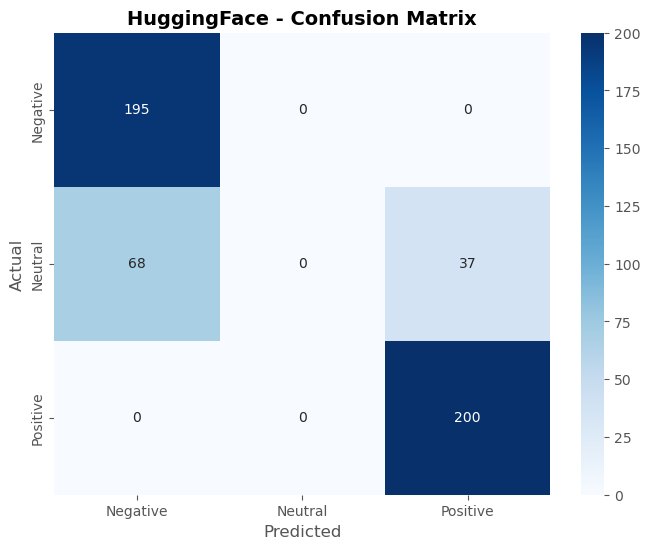


🎯 WHAT HUGGINGFACE PREDICTED:
  Negative: 263 reviews
  Neutral: 0 reviews
  Positive: 237 reviews



In [76]:
print("="*70)
print("HUGGINGFACE MODEL - FULL EVALUATION")
print("="*70)

# Convert labels to numbers
y_true = df['sentiment'].map(label_map)
y_pred_hf = df['huggingface_prediction'].map(label_map)

# Calculate metrics
hf_accuracy = accuracy_score(y_true, y_pred_hf)
hf_precision = precision_score(y_true, y_pred_hf, average='macro')
hf_recall = recall_score(y_true, y_pred_hf, average='macro')
hf_f1 = f1_score(y_true, y_pred_hf, average='macro')

print(f"\n📊 OVERALL METRICS:")
print(f"  Accuracy : {hf_accuracy:.2f}")
print(f"  Precision: {hf_precision:.2f}")
print(f"  Recall   : {hf_recall:.2f}")
print(f"  F1 Score : {hf_f1:.2f}")

# Detailed report
print("\n📋 DETAILED CLASSIFICATION REPORT:")
print(classification_report(y_true, y_pred_hf, 
                          target_names=['Negative', 'Neutral', 'Positive']))

# Confusion matrix
cm_hf = confusion_matrix(y_true, y_pred_hf)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_hf, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Negative','Neutral','Positive'],
            yticklabels=['Negative','Neutral','Positive'])
plt.title("HuggingFace - Confusion Matrix", fontsize=14, fontweight='bold')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# Show prediction counts
print("\n🎯 WHAT HUGGINGFACE PREDICTED:")
hf_counts = df['huggingface_prediction'].value_counts()
for sentiment in ['Negative', 'Neutral', 'Positive']:
    count = hf_counts.get(sentiment, 0)
    print(f"  {sentiment}: {count} reviews")

print("\n" + "="*70)

## 🤔 Surprising Result: HuggingFace Has the Same Problem!

**Wait... HuggingFace ALSO predicted ZERO neutrals?!**

Yes! Despite being a state-of-the-art model, it has the exact same neutral detection problem as VADER Original:

| Metric | Result | What it means |
|--------|--------|---------------|
| **Accuracy** | 79% | Same as VADER Original |
| **Neutral Precision** | 0.00 | Never predicted any review as Neutral |
| **Neutral Recall** | 0.00 | Found 0 out of 105 neutral reviews |
| **Negative/Positive** | Perfect! | 100% recall for both classes |

### Why Did This Happen?

**The Root Cause:** This specific DistilBERT model was trained for **binary classification** (POSITIVE vs NEGATIVE only):
- 🎯 Trained on: SST-2 dataset (Stanford Sentiment Treebank)
- 📊 Only 2 classes: POSITIVE and NEGATIVE
- ❌ No "NEUTRAL" or "MIXED" category in training data

**My Confidence-Based Solution Failed:**
- I tried: "Low confidence (<65%) = Neutral"
- Reality: The model is TOO confident! Most predictions are >99%
- Example: "It's okay" → 64% POSITIVE (barely made neutral threshold)
- Problem: Very few predictions fall in the 50-65% confidence range

### What's Actually in Your Data?

Let me check what HuggingFace actually predicted:

In [78]:
print("="*70)
print("WHAT DID HUGGINGFACE ACTUALLY PREDICT?")
print("="*70)

# Check what HuggingFace predicted
hf_pred_counts = df['huggingface_prediction'].value_counts()

print("\n📊 HuggingFace Predictions:")
for sentiment in ['Negative', 'Neutral', 'Positive']:
    count = hf_pred_counts.get(sentiment, 0)
    actual = (df['sentiment'] == sentiment).sum()
    print(f"  {sentiment:8s}: {count:3d} predicted (actual: {actual})")

print("\n📊 Actual Distribution:")
actual_counts = df['sentiment'].value_counts()
for sentiment in ['Negative', 'Neutral', 'Positive']:
    count = actual_counts.get(sentiment, 0)
    print(f"  {sentiment:8s}: {count:3d} reviews")

# Check the breakdown
print("\n📋 Where did the 105 neutrals go?")
neutral_reviews = df[df['sentiment'] == 'Neutral']
hf_neutral_predictions = neutral_reviews['huggingface_prediction'].value_counts()

for pred, count in hf_neutral_predictions.items():
    print(f"  • {count:3d} classified as {pred}")

print("\n" + "="*70)
print("💡 THE ISSUE: Binary model can't predict neutrals!")
print("   HuggingFace only knows POSITIVE or NEGATIVE")
print("   The confidence trick didn't work - model is too confident")
print("="*70)

WHAT DID HUGGINGFACE ACTUALLY PREDICT?

📊 HuggingFace Predictions:
  Negative: 263 predicted (actual: 195)
  Neutral :   0 predicted (actual: 105)
  Positive: 237 predicted (actual: 200)

📊 Actual Distribution:
  Negative: 195 reviews
  Neutral : 105 reviews
  Positive: 200 reviews

📋 Where did the 105 neutrals go?
  •  68 classified as Negative
  •  37 classified as Positive

💡 THE ISSUE: Binary model can't predict neutrals!
   HuggingFace only knows POSITIVE or NEGATIVE
   The confidence trick didn't work - model is too confident


##  STEP 0: Define Features (X) and Target (y)

Before building any machine learning model, we need to define:

###  **X (Features)** - The INPUT
- **What:** Review text that we use to make predictions
- **Column:** `cleaned_review`
- **Total samples:** 500 reviews
- **Example:** "not satisfied many bugs and issues..."

###  **y (Target)** - The OUTPUT
- **What:** Sentiment labels we want to predict
- **Column:** `sentiment_encoded`
- **Values:** 
  - 0 = Negative
  - 1 = Neutral
  - 2 = Positive
- **Distribution:**
  - Negative: 195 reviews
  - Neutral: 105 reviews
  - Positive: 200 reviews

###  **In Simple Terms:**
- **X** = The review text (INPUT) → What we feed to the model
- **y** = The sentiment (OUTPUT) → What we want the model to predict

---

##  STEP 1: Split into Training and Testing Sets

We split our data into two parts:
- **80% Training set:** Used to teach the model
- **20% Testing set:** Used to evaluate how well model learned

**Why split?**
- To check if model works on new, unseen data
- Prevents overfitting (memorizing instead of learning)

**Stratified split:** Keeps the same proportion of sentiments in both sets

---

##  STEP 2: TF-IDF Converter Settings

**What is TF-IDF?**
- Converts text words into numerical scores
- Important words get higher scores
- Common words (like "the", "and") get lower scores

**Our Settings:**

### 1️ **max_features = 1000**
- Only keep top 1000 most important words
- **Why?** Too many words = model memorizes instead of learns
- **Analogy:** Like focusing on 1000 most important facts for an exam

### 2️ **min_df = 3**
- Word must appear in at least 3 different reviews
- **Why?** Rare words (appear only once) are usually typos or not useful
- **Analogy:** Like ignoring facts mentioned by only 1 person

### 3️ **ngram_range = (1, 2)**
- Look at single words AND word pairs
- **Why?** "not good" means different than just "good"
- **Examples:**
  - Single word: "amazing"
  - Word pair: "not satisfied"

---

##  STEP 3: Convert Text to Numbers

**Process:**
1. **Training data:** Learn vocabulary from training reviews, then convert
2. **Testing data:** Use learned vocabulary to convert (don't learn from test data)

**Result:**
- Started with: Text reviews (strings)
- Ended with: 166 numerical features per review
- Ready for: Machine Learning models!

**Example vocabulary learned:** "amazing", "not good", "app is", "terrible", "worth"